# Random unitaries and random circuits

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 4 — Digital quantum circuits*

## 1. Introduction and motivation

What does a *typical* quantum state of $N$ qubits look like? What does a *generic* interacting dynamics do to a simple
initial state? How can one test a quantum processor on a task for which nobody knows the answer in advance? All three
questions lead to the same tool: **random unitaries**.

* **Typical states.** Draw a state "uniformly at random" from the Hilbert space and look at a small
  subsystem: it is almost maximally mixed, i.e. the state is almost maximally entangled (Page 1993). This is the
  cartoon picture of what chaotic many-body dynamics does to a state after a long time - it *scrambles* it - and it
  underlies modern explanations of why local observables of isolated quantum systems relax, as well as toy models of black holes.
* **Minimal models of quantum chaos.** A circuit of random two-qubit gates arranged like bricks in a wall is the
  simplest "dynamics" that is local and unitary and has no other structure (no energy conservation, no symmetries).
  It reproduces the universal features of chaotic Hamiltonian evolution - linear growth of entanglement, saturation at
  the Page value - and is much easier to analyse (Nahum *et al.* 2017; Fisher *et al.* 2023).
* **Benchmarking quantum processors.** The "quantum supremacy" experiments (Arute *et al.* 2019) ran random circuits on
  53 superconducting qubits and compared the measured bit strings with a classical simulation through the *linear
  cross-entropy benchmark* (XEB). The statistical theory behind it is the Porter-Thomas distribution of the output
  probabilities of a random state.
* **Randomised measurement protocols.** Randomised benchmarking, classical shadows
  ([notebook 24](../ch08_quantum_information_protocols/24_classical_shadows.ipynb)) and many
  tomography schemes average over random unitaries - in practice over the finite **Clifford group**, which imitates the
  uniform distribution well enough.
* **Numerical practice.** Random states and unitaries are the best *test inputs* for a simulator: they have no
  symmetry that could hide a bug.

**Road map.** Section 2 explains what "uniformly random" means for unitaries (the Haar measure) and shows a tempting
but wrong way to sample. Section 3 constructs Haar-random *states* from Gaussian vectors, Section 4 Haar-random
*unitaries* from the QR decomposition, including the subtle phase correction without which the result is wrong - we
make the error visible. Section 5 derives the Porter-Thomas distribution. Section 6 builds random brick-wall
circuits with `vmap`/`scan` and measures how entanglement grows and saturates. Section 7 constructs the 24-element
single-qubit Clifford group and tests in which sense it is "as good as Haar". Sections 8 and 9 are about random
circuit sampling from a discrete gate set, its simulation cost, and cross-entropy benchmarking with and without noise.

### What you will learn

*Physics*

* the Haar measure as the unique unitarily invariant distribution; typical states are nearly maximally entangled
  (Page value) and their output probabilities are exponentially distributed (Porter-Thomas);
* random circuits as minimal models of chaotic dynamics: linear entanglement growth, saturation depth $\propto N$,
  anticoncentration;
* Clifford gates: a finite group that reproduces Haar averages up to the third moment, but no further;
* what the linear XEB measures and why it estimates the fidelity of a noisy device.

*Numerical methods*

* sampling from the Haar measure: Gaussian vectors, QR decomposition with phase correction (Mezzadri);
* statistical validation of a sampler: moments, histograms, Monte-Carlo error bars $\propto 1/\sqrt M$;
* frame potentials as a quantitative test of "how random" a set of unitaries is;
* noisy circuits via quantum trajectories.

*Implementation practice*

* explicit PRNG keys, `jax.random.split`, reproducible randomness; `vmap` over keys to draw thousands of samples;
* "randomness is data, structure is static": circuits stored as arrays of gate matrices (or gate indices) so that one
  compiled program runs *every* random circuit; `lax.scan` over layers;
* honest timing of compile versus run; scaling $O(2^N)$ per gate up to $N=20$.

### Prerequisites

* [01 JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (PRNG keys, `vmap`, `scan`, `jit`);
* [05 Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) (`apply_gate`);
* [06 States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) (Schmidt decomposition,
  entanglement entropy, Page value);
* [07 Density matrices and channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb) (depolarising channel,
  trajectories), [08 Measurements](../ch03_matrix_free_engine/08_measurements.ipynb) (sampling bit strings);
* [09 Quantum gates and circuits](09_quantum_gates_and_circuits.ipynb) (gate set, circuits as lists, Clifford gates).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. What does "a random unitary" mean? The Haar measure

### 2.1 Uniform = invariant

"Pick a random number" is meaningless until a distribution is specified, and "uniform" needs a notion of volume.
For a point on a circle, *uniform* means: the distribution does not change when the circle is rotated. The same
principle defines the uniform distribution on the group $U(d)$ of $d\times d$ unitary matrices:

> The **Haar measure** is the (unique) probability distribution on $U(d)$ that is invariant under multiplication by any
> fixed unitary $V$: if $U$ is Haar distributed, so are $VU$ and $UV$.

We quote existence and uniqueness without proof (it holds for every compact group). Intuition: a Haar-random $U$ has
*no preferred basis* - whatever rotation $V$ you apply before or after, the statistics are unchanged. For $d=1$ the
group is the circle $\{e^{i\varphi}\}$ and the Haar measure is $d\varphi/2\pi$.

Similarly a **Haar-random state** is $U\lvert\psi_0\rangle$ for a fixed reference state $\lvert\psi_0\rangle$ and Haar-random
$U$: the uniform distribution on the unit sphere of the Hilbert space. For one qubit this sphere is, up to the global
phase, the Bloch sphere, and "uniform" has its everyday geometrical meaning: equal areas are equally likely.

### 2.2 A tempting mistake: uniform Euler angles

In notebook 09 we saw that every single-qubit gate is $e^{i\alpha}R_z(\beta)R_y(\gamma)R_z(\delta)$. So why not draw
the angles uniformly? Let us look at the state $U\lvert0\rangle$. Its polar angle on the Bloch sphere is exactly $\gamma$,
so $\langle Z\rangle=\cos\gamma$. If $\gamma$ is uniform in $[0,\pi]$, the density of $z=\cos\gamma$ is
$\frac{1}{\pi\sqrt{1-z^2}}$, which diverges at $z=\pm1$: the states crowd around the poles. For the uniform distribution
on a sphere, on the other hand, the area element is $\sin\gamma\,d\gamma\,d\varphi = d(\cos\gamma)\,d\varphi$: **$z=\cos\gamma$
must be uniform in $[-1,1]$** (Archimedes' "hat-box" theorem: slices of equal height have equal area). The angles
of a parametrisation are in general *not* uniformly distributed - one needs the Jacobian.

The experiment below draws 20000 "naive" unitaries and compares the histogram of $\langle Z\rangle$ with the correct
sampler of Section 3. First the folded engine recap with the primitives from earlier notebooks.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (copied from quantum_engine.py, the SmoQ.jax engine)
# Every function below is explained, with its mathematics and an independent check, in
# notebook 08b (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi


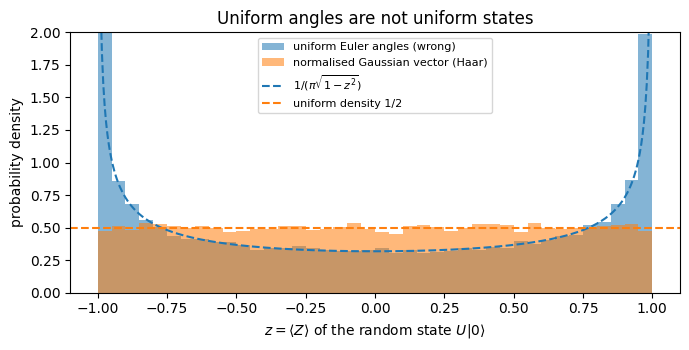

variance of z:  naive = 0.5003 (arcsine law: 1/2),  Haar = 0.3351 (uniform on [-1,1]: 1/3)


In [3]:
# ==============================================================================
# STEP 1: naive "uniform Euler angles" versus Haar: distribution of <Z> for U|0>
# ==============================================================================
M_SAMPLES = 20000                                   # number of random unitaries / states


def naive_random_gate(key):
    """WRONG sampler: Rz(beta) Ry(gamma) Rz(delta) with beta, delta in [0,2pi), gamma in [0,pi] all uniform."""
    b, g, d = jax.random.uniform(key, (3,)) * jnp.array([2 * jnp.pi, jnp.pi, 2 * jnp.pi])
    return rz(b) @ ry(g) @ rz(d)


def z_of_first_column(U):
    """<Z> of the state U|0> = first column of U:  |U_00|^2 - |U_10|^2."""
    return jnp.abs(U[0, 0]) ** 2 - jnp.abs(U[1, 0]) ** 2


def gaussian_state_1q(key):
    """Correct sampler (derived in Section 3): normalised complex Gaussian vector."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,)) + 1j * jax.random.normal(k2, (2,))
    return v / jnp.linalg.norm(v)


keys = jax.random.split(jax.random.PRNGKey(0), M_SAMPLES)          # one independent key per sample
z_naive = jax.vmap(lambda k: z_of_first_column(naive_random_gate(k)))(keys)
z_haar = jax.vmap(lambda k: z_of_first_column(gaussian_state_1q(k)[:, None]))(keys)

fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.linspace(-1, 1, 41)
ax.hist(np.asarray(z_naive), bins=bins, density=True, alpha=0.55, label="uniform Euler angles (wrong)")
ax.hist(np.asarray(z_haar), bins=bins, density=True, alpha=0.55, label="normalised Gaussian vector (Haar)")
zz = np.linspace(-0.995, 0.995, 400)
ax.plot(zz, 1 / (np.pi * np.sqrt(1 - zz ** 2)), "C0--", lw=1.5, label=r"$1/(\pi\sqrt{1-z^2})$")
ax.axhline(0.5, color="C1", ls="--", lw=1.5, label="uniform density 1/2")
ax.set_ylim(0, 2.0)
ax.set_xlabel(r"$z=\langle Z\rangle$ of the random state $U|0\rangle$")
ax.set_ylabel("probability density")
ax.set_title("Uniform angles are not uniform states")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"variance of z:  naive = {float(jnp.var(z_naive)):.4f} (arcsine law: 1/2),  "
      f"Haar = {float(jnp.var(z_haar)):.4f} (uniform on [-1,1]: 1/3)")

The naive sampler follows the arcsine law and over-represents states near the poles $\lvert0\rangle,\lvert1\rangle$ (variance of
$z$ close to $1/2$), the correct sampler gives a flat histogram (variance close to $1/3$). Any average computed with
the naive sampler - e.g. the mean entanglement generated by a "random" gate - would be biased.

> **JAX practice.** JAX has no global random state. Every random function takes an explicit **key**;
> `jax.random.split(key, M)` produces $M$ statistically independent keys, and `vmap` over these keys draws $M$
> samples in parallel. The same key always gives the same numbers: the notebook is reproducible bit by bit, and each
> sample can be regenerated in isolation for debugging (notebook 01).

## 3. Haar-random states from Gaussian vectors

**Claim.** Let $g=(g_1,\dots,g_D)$ have independent complex Gaussian entries (real and imaginary parts independent
normal variables of equal variance). Then $\lvert\psi\rangle = g/\lVert g\rVert$ is Haar distributed.

**Proof.** The joint probability density of $g$ is
$\prod_i \frac{1}{\pi\sigma^2}e^{-|g_i|^2/\sigma^2}\propto e^{-\lVert g\rVert^2/\sigma^2}$: *it depends on $g$ only through
its norm*. A unitary $V$ preserves the norm (and has unit Jacobian - as a real linear map on $\mathbb R^{2D}$ its
determinant is $\lvert\det V\rvert^2=1$), so $Vg$ has the same density as $g$. Hence the
direction $g/\lVert g\rVert$ has a distribution on the unit sphere that is invariant under all unitaries. Any two unit
vectors are related by some unitary, so the sphere is a single orbit of $U(D)$, and on a single orbit there is only one
invariant probability measure: the uniform one. $\blacksquare$

This is the engine function `haar_state` (the state is returned as a rank-$N$ tensor). The argument works
because the Gaussian is the distribution whose product form is rotation invariant. Normalising a vector of
*uniform* random numbers does **not** give a uniform direction (Exercise 1).

In [4]:
# ==============================================================================
# FINAL ENGINE VERSION  (verbatim from quantum_engine.py -- this is what later notebooks reuse)
# ==============================================================================
# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


**Checkpoints.** For a Haar state in dimension $D=2^N$ the probabilities $p_i=\lvert\psi_i\rvert^2$ satisfy (we derive the
full distribution in Section 5)

$$ \mathbb E[p_i]=\frac1D,\qquad \mathbb E[p_i^2]=\frac{2}{D(D+1)},\qquad \mathbb E\big[\lvert\psi\rangle\langle\psi\rvert\big]=\frac{\mathbb 1}{D}, $$

where $\mathbb 1$ is the $D\times D$ identity matrix.
The last statement says that the *average* over all pure states is the maximally mixed state - complete ignorance.
We test these with $M$ samples; a Monte-Carlo average has a statistical error $\sigma/\sqrt M$, so the checks are
formulated as "deviation in units of the standard error", not with `TOL`.

In [5]:
# ==============================================================================
# CHECKPOINT: first and second moments of Haar-random states (N = 3 qubits, D = 8)
# ==============================================================================
N_chk, M_chk = 3, 20000
D_chk = 2 ** N_chk
states = jax.vmap(lambda k: haar_state(k, N_chk))(jax.random.split(jax.random.PRNGKey(1), M_chk))   # (M, 2,2,2)
probs = jnp.abs(states.reshape(M_chk, D_chk)) ** 2

print(f"norms: max |1 - <psi|psi>| = {float(jnp.max(jnp.abs(jnp.sum(probs, axis=1) - 1))):.1e}")
for name, sample, exact in (("E[p_0]  ", probs[:, 0], 1 / D_chk), ("E[p_0^2]", probs[:, 0] ** 2, 2 / (D_chk * (D_chk + 1)))):
    mean, sem = float(jnp.mean(sample)), float(jnp.std(sample) / np.sqrt(M_chk))
    print(f"{name} = {mean:.5f} +- {sem:.5f}   exact {exact:.5f}   ({abs(mean - exact) / sem:.1f} standard errors)")
    assert abs(mean - exact) < 5 * sem

rho_avg = jnp.einsum("mi,mj->ij", states.reshape(M_chk, D_chk), states.reshape(M_chk, D_chk).conj()) / M_chk
print(f"average state: max |E[|psi><psi|] - 1/D| = {float(jnp.max(jnp.abs(rho_avg - jnp.eye(D_chk) / D_chk))):.4f}"
      f"   (expected statistical scatter ~ 1/(D sqrt(M)) = {1 / (D_chk * np.sqrt(M_chk)):.4f})")

norms: max |1 - <psi|psi>| = 6.7e-16


E[p_0]   = 0.12540 +- 0.00078   exact 0.12500   (0.5 standard errors)
E[p_0^2] = 0.02784 +- 0.00033   exact 0.02778   (0.2 standard errors)


average state: max |E[|psi><psi|] - 1/D| = 0.0015   (expected statistical scatter ~ 1/(D sqrt(M)) = 0.0009)


The sample moments agree with the exact values within the standard error, and the averaged projector is the
maximally mixed state up to statistical scatter (the printed number is the *largest* of the 64 matrix elements of the
deviation, hence somewhat above the typical scatter of a single element).

## 4. Haar-random unitaries from the QR decomposition

### 4.1 The recipe and why it needs a phase fix

A unitary matrix is a set of $d$ orthonormal vectors. A natural idea: take $d$ random Gaussian vectors - the columns
of a **Ginibre matrix** $G$ with independent complex Gaussian entries - and orthonormalise them by the Gram-Schmidt
procedure. In matrix language Gram-Schmidt *is* the QR decomposition

$$ G = QR,\qquad Q \text{ unitary},\quad R \text{ upper triangular}, $$

where column $j$ of $Q$ is column $j$ of $G$ made orthogonal to the previous columns and normalised, and $R$ stores the
coefficients. Is $Q$ Haar distributed? The argument would go like this: the Ginibre ensemble is invariant, $VG\sim G$
(same proof as in Section 3, applied to every column). If $G=QR$ then $VG=(VQ)R$ is a QR decomposition of $VG$, so
"$Q(VG) = V\,Q(G)$", and the distribution of $Q$ is invariant under left multiplication: Haar.

The gap in the argument is the word "*a*" QR decomposition. **The QR decomposition is not unique**: for any diagonal
matrix of phases $\Lambda=\mathrm{diag}(e^{i\phi_1},\dots,e^{i\phi_d})$,

$$ G = QR = (Q\Lambda)(\Lambda^{\dagger}R) $$

is another one. The map $G\mapsto Q$ is only well defined after fixing a convention, and the argument
"$Q(VG)=VQ(G)$" is valid only if the convention does not depend on the basis. The convention **$R_{jj}>0$**
(the one Gram-Schmidt produces) has this property: the condition constrains $R$ alone, and replacing $G$ by $VG$ leaves
$R$ unchanged, so the selected $Q$ simply becomes $VQ$. Numerical libraries do
something else: LAPACK's Householder algorithm returns a *real* diagonal of $R$ whose *signs* depend on the entries of
$G$ in a basis-dependent way. The resulting $Q$ is **not** Haar distributed.

Two details are worth separating here, because the first one alone would be harmless. If the phases $\Lambda$ were
drawn *independently* of $G$, then $Q=U\Lambda^\dagger$ with $U$ Haar would still be Haar, since the Haar measure is
invariant under multiplication by any fixed unitary. The damage is done by the *correlation*: the sign is a function
of $G$, hence of $Q$. Concretely, LAPACK's first Householder step returns $R_{11}=-\mathrm{sign}(\mathrm{Re}\,G_{11})\lVert G_{\cdot1}\rVert$
and therefore a first column $Q_{\cdot1}=G_{\cdot1}/R_{11}$ whose leading entry has
$\mathrm{Re}\,Q_{11}=-\lvert\mathrm{Re}\,G_{11}\rvert/\lVert G_{\cdot1}\rVert\le0$ - a hard, basis-dependent constraint that a Haar-random
matrix violates half of the time. The cure (Mezzadri 2007) is one line:

$$ \Lambda = \mathrm{diag}\Big(\frac{R_{jj}}{|R_{jj}|}\Big),\qquad U = Q\Lambda , $$

which converts the library's decomposition into the one with positive diagonal $R' = \Lambda^\dagger R$. In code,
multiplying $Q$ from the right by a diagonal matrix is a broadcast over columns: `Q * ph[None, :]`.

In [6]:
# ==============================================================================
# FINAL ENGINE VERSION  (verbatim from quantum_engine.py -- this is what later notebooks reuse)
# ==============================================================================
# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


### 4.2 Making the error visible: eigenphase statistics

A sharp test uses the eigenvalues $e^{i\varphi_k}$ of $U$. For Haar-random unitaries the density of eigenphases is
flat, $\rho(\varphi)=1/2\pi$: if $U$ is Haar then so is $e^{i\alpha}U$, which shifts all eigenphases by $\alpha$, so no
phase can be preferred. We also check $\mathbb E\lvert\mathrm{Tr}\,U\rvert^2=1$ (quoted: a standard result for the Haar
measure, valid for every $d$).

We draw 20000 matrices of size $d=2$ and $d=4$ with and without the phase fix (`vmap` over keys), and compute
the eigenvalues with NumPy (the non-Hermitian eigenvalue solver is one of the few routines that JAX offers on CPU only).

d=2  library QR: max |Im R_jj| = 0.0e+00,  fraction of negative R_jj = 0.499   <- real, but not positive
d=2  QR without phase fix              : E|Tr U|^2 = 1.352 +- 0.008   (Haar: 1),  smallest |phi|/pi among 40000 eigenphases = 0.2428
d=2  QR with phase fix (haar_unitary)  : E|Tr U|^2 = 1.001 +- 0.007   (Haar: 1),  smallest |phi|/pi among 40000 eigenphases = 0.0000


d=4  library QR: max |Im R_jj| = 0.0e+00,  fraction of negative R_jj = 0.498   <- real, but not positive


d=4  QR without phase fix              : E|Tr U|^2 = 1.851 +- 0.009   (Haar: 1),  smallest |phi|/pi among 80000 eigenphases = 0.1151


d=4  QR with phase fix (haar_unitary)  : E|Tr U|^2 = 0.999 +- 0.007   (Haar: 1),  smallest |phi|/pi among 80000 eigenphases = 0.0000


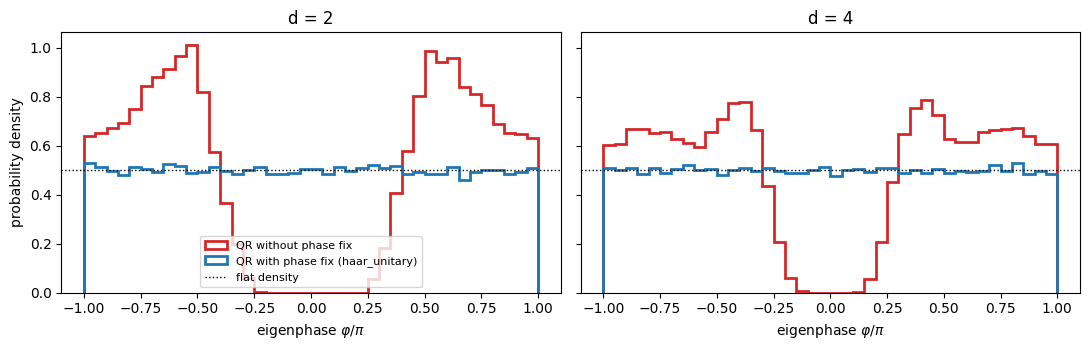

In [7]:
# ==============================================================================
# STEP 2: QR with and without the phase fix -- eigenphase histograms
# ==============================================================================
def qr_without_fix(key, d):
    """Q factor of a Ginibre matrix, as returned by the library.  NOT Haar distributed!"""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    return Q, jnp.diagonal(R)


keys = jax.random.split(jax.random.PRNGKey(2), M_SAMPLES)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, d in zip(axes, (2, 4)):
    Q_raw, R_diag = jax.vmap(lambda k: qr_without_fix(k, d))(keys)
    U_haar = jax.vmap(lambda k: haar_unitary(k, d))(keys)
    print(f"d={d}  library QR: max |Im R_jj| = {float(jnp.max(jnp.abs(jnp.imag(R_diag)))):.1e},  "
          f"fraction of negative R_jj = {float(jnp.mean(jnp.real(R_diag) < 0)):.3f}   <- real, but not positive")
    for U_set, label, color in ((Q_raw, "QR without phase fix", "C3"), (U_haar, "QR with phase fix (haar_unitary)", "C0")):
        U_np = np.asarray(U_set)
        phases = np.angle(np.linalg.eigvals(U_np)).ravel()
        tr2 = np.abs(np.trace(U_np, axis1=1, axis2=2)) ** 2
        ax.hist(phases / np.pi, bins=40, range=(-1, 1), density=True, histtype="step", lw=2, color=color, label=label)
        print(f"d={d}  {label:34s}: E|Tr U|^2 = {tr2.mean():.3f} +- {tr2.std() / np.sqrt(M_SAMPLES):.3f}   (Haar: 1),"
              f"  smallest |phi|/pi among {phases.size} eigenphases = {np.abs(phases).min() / np.pi:.4f}")
    ax.axhline(0.5, color="k", ls=":", lw=1, label="flat density")
    ax.set_xlabel(r"eigenphase $\varphi/\pi$")
    ax.set_title(f"d = {d}")
axes[0].set_ylabel("probability density")
axes[0].legend(fontsize=8, loc="lower center")
plt.tight_layout()
plt.show()

The library's $R$ has a real diagonal, but about half of its entries are negative. Without the fix the eigenphase
density is grossly non-uniform: there is a *hard gap* around $\varphi=0$ - among the $40000$ eigenphases at $d=2$ not
one comes closer to $0$ than $0.24\pi$, among the $80000$ at $d=4$ none closer than $0.12\pi$, so an eigenvalue near
$+1$ is not merely rare but impossible - and $\mathbb E\lvert\mathrm{Tr}U\rvert^2$ is far from 1. That is the
constraint $\mathrm{Re}\,Q_{11}\le0$ of Section 4.1 showing up in the spectrum. With the fix the histogram is flat within statistical
noise, the smallest eigenphase found is $0.0000\pi$ to the printed precision, and $\mathbb E\lvert\mathrm{Tr}U\rvert^2=1$ within
the error bar. Both samplers return perfectly *unitary* matrices; a test of
unitarity alone would never have revealed the problem.

> **Common pitfall.** "It is unitary and looks random" is not a validation of a random-unitary sampler. Test
> *statistical* properties with known exact values (moments, eigenphase density). The same warning applies to
> `scipy.linalg.qr`, `numpy.linalg.qr` and their analogues in every language.

> **Numerical practice.** It is tempting to code the Gram-Schmidt procedure by hand, since it delivers $R_{jj}>0$ with
> no phase fix at all. Resist it. Measuring the departure from orthogonality of the computed $Q$ by
> $\lVert \mathbb 1-Q^\dagger Q\rVert$, classical Gram-Schmidt gives $O(\varepsilon\,\kappa^2)$ and the modified variant
> $O(\varepsilon\,\kappa)$, where $\varepsilon$ is the machine epsilon and $\kappa$ the condition number, while the
> Householder algorithm used by the libraries gives $O(\varepsilon)$ whatever $\kappa$ (Numerical Recipes, 3rd ed.,
> Section 2.10). For a Ginibre matrix $\kappa$ is modest and all three would do, but the habit is the point: call the
> library and repair the *convention* afterwards, rather than reimplementing the *algorithm*.

### 4.3 More checkpoints: unitarity and the moments of matrix elements

Since the first column of a Haar unitary is a Haar state, the moments of Section 3 carry over to every matrix element:
$\mathbb E\lvert U_{ij}\rvert^2=1/d$ and $\mathbb E\lvert U_{ij}\rvert^4=2/(d(d+1))$. We also check unitarity for $d=2,4,8$,
i.e. one-, two- and three-qubit gates, and apply an $8\times8$ Haar unitary to three non-adjacent qubits of a register.

In [8]:
# ==============================================================================
# CHECKPOINT: unitarity, moments of |U_ij|^2, and a 3-qubit Haar gate applied through apply_gate
# ==============================================================================
for d in (2, 4, 8):
    U_set = jax.vmap(lambda k: haar_unitary(k, d))(jax.random.split(jax.random.PRNGKey(3), 5000))
    unit_err = float(jnp.max(jnp.abs(jnp.einsum("mji,mjk->mik", U_set.conj(), U_set) - jnp.eye(d))))   # U^dag U - 1
    a2 = jnp.abs(U_set[:, 0, 1]) ** 2
    m1, s1 = float(jnp.mean(a2)), float(jnp.std(a2) / np.sqrt(5000))
    m2, s2 = float(jnp.mean(a2 ** 2)), float(jnp.std(a2 ** 2) / np.sqrt(5000))
    print(f"d={d}: |U^dag U - 1|_max = {unit_err:.1e} | E|U_01|^2 = {m1:.4f}+-{s1:.4f} (exact {1 / d:.4f}) | "
          f"E|U_01|^4 = {m2:.4f}+-{s2:.4f} (exact {2 / (d * (d + 1)):.4f})")
    assert unit_err < 100 * TOL and abs(m1 - 1 / d) < 5 * s1 and abs(m2 - 2 / (d * (d + 1))) < 5 * s2

psi = apply_gate(zero_state(6), haar_unitary(jax.random.PRNGKey(4), 8), [0, 2, 5])       # k = 3, non-adjacent qubits
print(f"3-qubit Haar gate on qubits (0,2,5) of a 6-qubit register: norm = {float(jnp.linalg.norm(psi)):.12f}")
print("entanglement entropy of qubit 1 (untouched) with the rest:", f"{float(entanglement_entropy(psi, [1])):.2e} bit")

d=2: |U^dag U - 1|_max = 1.3e-15 | E|U_01|^2 = 0.4995+-0.0041 (exact 0.5000) | E|U_01|^4 = 0.3337+-0.0042 (exact 0.3333)


d=4: |U^dag U - 1|_max = 1.3e-15 | E|U_01|^2 = 0.2455+-0.0027 (exact 0.2500) | E|U_01|^4 = 0.0971+-0.0019 (exact 0.1000)


d=8: |U^dag U - 1|_max = 1.8e-15 | E|U_01|^2 = 0.1235+-0.0015 (exact 0.1250) | E|U_01|^4 = 0.0272+-0.0007 (exact 0.0278)


3-qubit Haar gate on qubits (0,2,5) of a 6-qubit register: norm = 1.000000000000


entanglement entropy of qubit 1 (untouched) with the rest: 5.32e-15 bit


All matrices are unitary to rounding, the second and fourth moments agree with $1/d$ and $2/(d(d+1))$ within the
statistical error, and a three-qubit random gate acts on arbitrary axes of the state tensor while leaving the other
qubits in a product state (entropy 0).

> **Numerical practice.** A Haar unitary on $N$ qubits costs $O(8^N)$ to generate (QR of a $2^N\times2^N$ matrix) and
> $4^N$ numbers to store. If you need a Haar-random *state*, never generate a unitary: `haar_state` costs $O(2^N)$.
> If you need scrambling *dynamics* on many qubits, use circuits of small random gates (Section 6).

## 5. The Porter-Thomas distribution

Measure a Haar-random state in the computational basis. The probability of the bit string $s$ is
$p_s=\lvert\psi_s\rvert^2$. How are these $D=2^N$ numbers distributed?

**Derivation.** Use the Gaussian construction $\psi_s=g_s/\lVert g\rVert$ and normalise the Gaussians such that
$\mathbb E\lvert g_s\rvert^2=1$, i.e. real and imaginary parts have variance $1/2$.

1. $w=\lvert g_s\rvert^2 = (\mathrm{Re}\,g_s)^2+(\mathrm{Im}\,g_s)^2$. In polar coordinates the Gaussian density
   $\frac1\pi e^{-r^2}\,r\,dr\,d\phi$ becomes, with $w=r^2$ and $dw=2r\,dr$, simply $e^{-w}dw$: **$\lvert g_s\rvert^2$ is
   exponentially distributed** with mean 1.
2. The norm $\lVert g\rVert^2=\sum_{s}\lvert g_s\rvert^2$ is a sum of $D$ such variables: mean $D$, standard deviation
   $\sqrt D$. For $D\gg1$ it is sharply concentrated, $\lVert g\rVert^2\approx D$.
3. Hence $D\,p_s \approx \lvert g_s\rvert^2$:

$$ \boxed{\;\rho(x)=e^{-x}\;\;\text{for}\;\;x=D\,p\;} \qquad\text{(Porter-Thomas distribution).} $$

Here $\rho$ is a probability *density*: $\rho(x)\,dx$ is the probability that $Dp$ falls in $[x,x+dx]$.
The exact finite-$D$ law for a single probability, which we quote, is the density
$\rho_D(p)=(D-1)(1-p)^{D-2}$ on $p\in[0,1]$ - a Beta distribution with parameters $(1,D-1)$, whose moments
$\mathbb E[p]=1/D$ and $\mathbb E[p^2]=2/(D(D+1))$ are exactly the ones checked in Section 3. Substituting
$p=x/D$ gives $\frac{D-1}{D}(1-x/D)^{D-2}\to e^{-x}$: the exponential is the $D\to\infty$ limit.
The name comes from nuclear physics, where Porter and Thomas (1956) found this law for the fluctuations of
neutron resonance widths - an early signature of quantum chaos.

Consequences: the output distribution of a random state is far from uniform. A fraction $1-e^{-1}\approx63\%$ of the
bit strings is *less* likely than uniform ($x<1$), a few are much more likely. The second moment is
$\mathbb E[x^2]=2$, so the **collision probability** is $\sum_sp_s^2\approx 2/D$, twice that of the uniform distribution
(exactly: $2/(D+1)$). Remember the quantity $D\sum_sp_s^2$: it is 1 for the uniform distribution, 2 for Porter-Thomas
and $D$ for a basis state; it will serve as our "speckle contrast".

**How large is the largest probability?** Treating the $D$ variables $x_s$ as independent exponentials,

$$ \Pr\big(\max_s x_s < a\big)=(1-e^{-a})^D\;\approx\;\exp\big(-e^{-(a-\ln D)}\big), $$

a Gumbel distribution centred at $\ln D$. Its mean is $\ln D+\gamma$ with $\gamma=0.5772$ (Euler's constant) and its
standard deviation is $\pi/\sqrt6\approx1.28$, independent of $D$. The most likely bit string therefore has a
probability of order $(\ln D)/D$: larger than the uniform $1/D$ only by a *logarithmic* factor. A random state spreads
its weight over the whole Hilbert space; it is **anticoncentrated**.

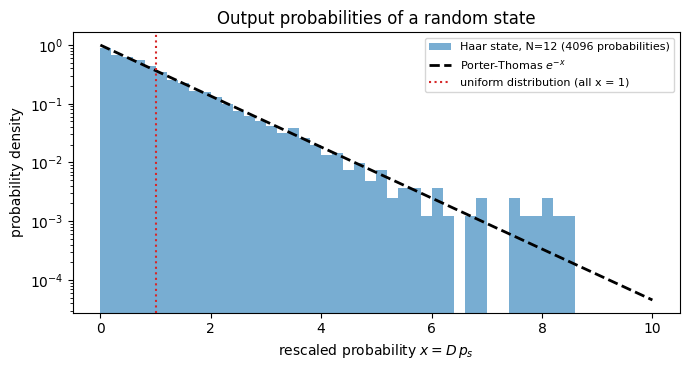

fraction of bit strings with p < 1/D : 0.638    (1 - 1/e = 0.632)
D * sum_s p_s^2                      : 2.013    (2D/(D+1) = 2.000)
largest probability                  : 8.49/D   (Gumbel: mean ln D + gamma = 8.89, spread pi/sqrt(6) = 1.28)


In [9]:
# ==============================================================================
# STEP 3: Porter-Thomas distribution of the output probabilities of a Haar state (N = 12)
# ==============================================================================
N_pt = 12
D_pt = 2 ** N_pt
psi_haar = haar_state(jax.random.PRNGKey(5), N_pt)
x_haar = np.asarray(D_pt * jnp.abs(psi_haar.reshape(-1)) ** 2)            # D * p_s  for all 4096 bit strings

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(x_haar, bins=50, range=(0, 10), density=True, alpha=0.6, label=f"Haar state, N={N_pt} ({D_pt} probabilities)")
xx = np.linspace(0, 10, 200)
ax.plot(xx, np.exp(-xx), "k--", lw=2, label=r"Porter-Thomas $e^{-x}$")
ax.axvline(1.0, color="C3", lw=1.5, ls=":", label="uniform distribution (all x = 1)")
ax.set_yscale("log")
ax.set_xlabel(r"rescaled probability $x = D\,p_s$")
ax.set_ylabel("probability density")
ax.set_title("Output probabilities of a random state")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"fraction of bit strings with p < 1/D : {np.mean(x_haar < 1):.3f}    (1 - 1/e = {1 - np.exp(-1):.3f})")
print(f"D * sum_s p_s^2                      : {np.mean(x_haar ** 2):.3f}    (2D/(D+1) = {2 * D_pt / (D_pt + 1):.3f})")
EULER_GAMMA = 0.5772156649015329
print(f"largest probability                  : {x_haar.max():.2f}/D   "
      f"(Gumbel: mean ln D + gamma = {np.log(D_pt) + EULER_GAMMA:.2f}, spread pi/sqrt(6) = {np.pi / np.sqrt(6):.2f})")

On the logarithmic scale the histogram is a straight line over three decades: the exponential law. About 63% of the
bit strings are less probable than uniform, the collision probability is twice the uniform value, and the most likely
bit string is only about $\ln D$ times more probable than average - the observed maximum sits within one Gumbel
standard deviation of the predicted mean $\ln D+\gamma$. The distribution is spread over the whole Hilbert
space (it is *anticoncentrated*) and yet it has a characteristic "speckle" structure, like laser light scattered from
a rough surface. It is this structure that cross-entropy benchmarking exploits (Section 9).

## 6. Random brick-wall circuits: how entanglement is born

### 6.1 The model

A Haar unitary on all $N$ qubits is a mathematical idealisation: generic $2^N\times2^N$ unitaries need exponentially
many elementary gates. Physical dynamics is **local**. The minimal local model is the *brick-wall circuit*: in even
layers Haar-random two-qubit gates act on the bonds $(0,1),(2,3),\dots$, in odd layers on $(1,2),(3,4),\dots$; every
gate is drawn independently. One layer is exactly the structure of one half Trotter step of a nearest-neighbour
Hamiltonian (notebook 09, Section 9) - with the interaction replaced by "anything".

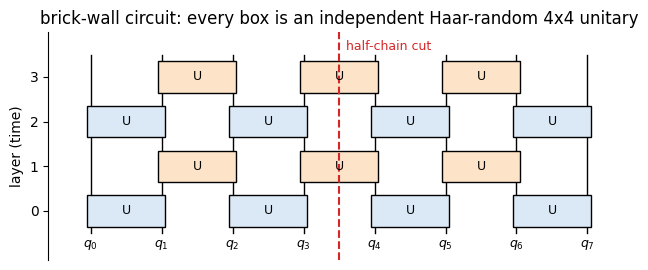

In [10]:
# ==============================================================================
# Picture: the brick-wall geometry (time runs upwards)
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.5, 2.8))
N_pic, depth_pic = 8, 4
for layer in range(depth_pic):
    for q in range(layer % 2, N_pic - 1, 2):
        ax.add_patch(plt.Rectangle((q - 0.05, layer + 0.15), 1.1, 0.7, fc="#dbe9f6" if layer % 2 == 0 else "#fde3c8", ec="k"))
        ax.text(q + 0.5, layer + 0.5, "U", ha="center", va="center", fontsize=9)
for q in range(N_pic):
    ax.plot([q, q], [0, depth_pic], color="k", lw=1, zorder=0)
    ax.text(q, -0.3, rf"$q_{{{q}}}$", ha="center", fontsize=9)
ax.axvline(N_pic / 2 - 0.5, color="C3", ls="--", lw=1.5)
ax.text(N_pic / 2 - 0.4, depth_pic + 0.1, "half-chain cut", color="C3", fontsize=9)
ax.set_ylabel("layer (time)")
ax.set_yticks(np.arange(depth_pic) + 0.5, [str(l) for l in range(depth_pic)])
ax.set_xticks([])
ax.set_xlim(-0.6, N_pic - 0.4)
ax.set_ylim(-0.6, depth_pic + 0.5)
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title("brick-wall circuit: every box is an independent Haar-random 4x4 unitary")
plt.tight_layout()
plt.show()

The engine provides a compact implementation, `brickwall(key, psi, depth)`, which draws and applies the gates layer by
layer in a Python loop:

In [11]:
# ==============================================================================
# FINAL ENGINE VERSION  (verbatim from quantum_engine.py -- this is what later notebooks reuse)
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def brickwall(key, psi, depth, periodic=False):
    """Random brick-wall circuit: layers of Haar-random 2-qubit gates on even bonds, then odd bonds, ...
    Depth ~ N turns a product state into a (nearly) Haar-random state: volume-law entanglement (Page)."""
    N = psi.ndim
    for layer in range(depth):
        bonds = [(i, i + 1) for i in range(layer % 2, N - 1, 2)]
        if periodic and N % 2 == 0 and layer % 2 == 1:
            bonds.append((N - 1, 0))
        key, *ks = jax.random.split(key, len(bonds) + 1)
        for k, b in zip(ks, bonds):
            psi = apply_gate(psi, haar_unitary(k, 4), b)
    return psi


### 6.2 Randomness is data, structure is static

For the experiments below we want (i) observables after *every* layer, (ii) averages over many circuit realisations
and (iii) later the *same* circuit with and without noise. A design that serves all three separates **generation**
from **execution**:

* a circuit is stored as *data*: two arrays of gate matrices, `U_even[l, j]` and `U_odd[l, j]` of shapes
  $(L, n_{\rm bonds}, 4, 4)$, for $L$ double layers (even layer followed by odd layer). Drawing them is one `vmap` of
  `haar_unitary` over a batch of keys;
* execution is a `lax.scan` over the leading axis $L$: the body applies one double layer - its *structure* (which
  bonds) is static Python, its *matrices* are the traced slices `U_even[l]`, `U_odd[l]`. The program is compiled once
  and is valid for every random circuit of that shape;
* `vmap` over circuit keys then runs a whole ensemble of circuits in parallel.

The observable recorded after each of the $2L$ layers is a small vector: the half-chain entanglement entropy (from the
singular values of the state reshaped into a $2^{N/2}\times2^{N/2}$ matrix, notebook 06) and the speckle contrast
$D\sum_sp_s^2$ of Section 5.

In [12]:
# ==============================================================================
# STEP 4: brick-wall circuits as arrays of gates; execution = scan over double layers
# ==============================================================================
def random_brickwall_circuit(key, N, n_double):
    """Draw the gates of a brick-wall circuit with 2*n_double layers.

    Returns (U_even, U_odd) with shapes (n_double, N//2, 4, 4) and (n_double, (N-1)//2, 4, 4).
    JAX   one vmap of `haar_unitary` over a batch of independent keys -- no Python loop over gates.
    """
    n_even, n_odd = N // 2, (N - 1) // 2
    k_even, k_odd = jax.random.split(key)
    draw = jax.vmap(lambda k: haar_unitary(k, 4))
    U_even = draw(jax.random.split(k_even, n_double * n_even)).reshape(n_double, n_even, 4, 4)
    U_odd = draw(jax.random.split(k_odd, n_double * n_odd)).reshape(n_double, n_odd, 4, 4)
    return U_even, U_odd


def apply_bond_layer(psi, U_layer, parity):
    """Apply U_layer[j] to bond (parity + 2j, parity + 2j + 1) for all j.  `parity` is static (0 = even, 1 = odd)."""
    for j in range(U_layer.shape[0]):
        psi = apply_gate(psi, U_layer[j], (parity + 2 * j, parity + 2 * j + 1))
    return psi


def layer_diagnostics(psi):
    """[ half-chain entanglement entropy in bits ,  speckle contrast D * sum_s p_s^2 ]."""
    N = psi.ndim
    return jnp.stack([entanglement_entropy(psi, list(range(N // 2))), 2 ** N * jnp.sum(jnp.abs(psi) ** 4)])


def run_brickwall(circuit, psi, observe=layer_diagnostics):
    """Run a brick-wall circuit; returns (final state, observe(psi) after each of the 2*n_double layers)."""
    def double_layer(psi, gates):
        U_even_l, U_odd_l = gates
        psi = apply_bond_layer(psi, U_even_l, 0)
        obs_even = observe(psi)
        psi = apply_bond_layer(psi, U_odd_l, 1)
        return psi, jnp.stack([obs_even, observe(psi)])

    psi, obs = lax.scan(double_layer, psi, circuit)                  # scan slices BOTH arrays of the tuple along axis 0
    return psi, obs.reshape((-1,) + obs.shape[2:])                   # (n_double, 2, ...) -> (2 n_double, ...)


# CHECKPOINT (N = 4, one double layer): against the textbook construction with Kronecker products
circ4 = random_brickwall_circuit(jax.random.PRNGKey(6), 4, 1)
psi_in = haar_state(jax.random.PRNGKey(7), 4)
psi_out, _ = run_brickwall(circ4, psi_in)
dense_even = jnp.kron(circ4[0][0, 0], circ4[0][0, 1])                               # U_(0,1) (x) U_(2,3)
dense_odd = jnp.kron(jnp.kron(jnp.eye(2), circ4[1][0, 0]), jnp.eye(2))             # 1 (x) U_(1,2) (x) 1
err = float(jnp.max(jnp.abs(psi_out.reshape(-1) - dense_odd @ dense_even @ psi_in.reshape(-1))))
print(f"scan/einsum brick wall vs dense kron construction: max error = {err:.1e}")
assert err < 100 * TOL

# the engine's loop version on the same task (different key bookkeeping => a different random circuit, same statistics)
psi_engine = brickwall(jax.random.PRNGKey(6), zero_state(8), 24)      # eager: unrolling 84 QR decompositions under jit compiles slowly
print(f"engine `brickwall`, N=8, depth 24: norm = {float(jnp.linalg.norm(psi_engine)):.12f}, "
      f"half-chain entropy = {float(entanglement_entropy(psi_engine, [0, 1, 2, 3])):.3f} bit")

scan/einsum brick wall vs dense kron construction: max error = 8.1e-17


engine `brickwall`, N=8, depth 24: norm = 1.000000000000, half-chain entropy = 3.340 bit


### 6.3 Entanglement growth and saturation at the Page value

We start from the product state $\lvert0\dots0\rangle$ and record the half-chain entanglement entropy after every layer,
averaged over an ensemble of random circuits, for several system sizes.

What should we expect? (i) A gate can change the entanglement across a cut only if it *acts across the cut*, and a
single two-qubit gate can change the entropy by at most 2 bits. The bound follows from subadditivity: let the gate act
on qubit $a\in A$ and qubit $b\in B$, and write $A=\{a\}\cup A'$. The gate does not touch $A'$, so $S_{A'}$ is the same
before and after, while both $S_A$ obey $\lvert S_{A'}-S_a\rvert\le S_A\le S_{A'}+S_a$ with $S_a\le1$ bit; the two
inequalities together give $\lvert\Delta S_A\rvert\le 2$ bits. In our geometry one gate crosses the
central cut every second layer - so the entropy can grow at most **linearly** in depth. (ii) It cannot exceed $N/2$ bits. For a Haar-random state Page (1993) computed
the average entropy of a subsystem of dimension $m$ in a bipartite system of dimensions $m\le n$ (quoted, in nats):

$$ \langle S\rangle = \sum_{k=n+1}^{mn}\frac1k-\frac{m-1}{2n}\;\approx\;\ln m-\frac{m}{2n}. $$

For equal halves this is $N/2$ bits minus the famous deficit $1/(2\ln2)\approx0.72$ bit, independent of $N$: a random
state is almost, but not quite, maximally entangled.

128 circuits x 32 layers, including compilation: 32.8 s


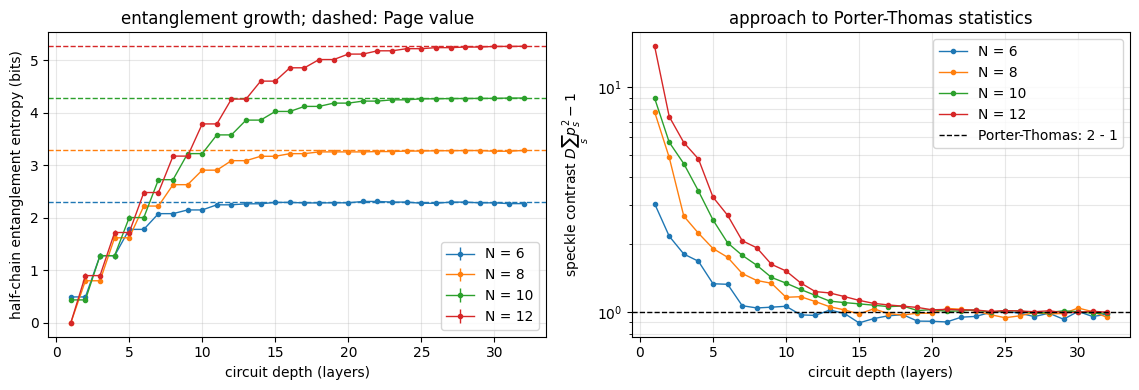

  N           S(final)     Page    D sum p^2 (final)   2D/(D+1)  layers to 90% of Page   growth, layers 2-8 (bit/layer)
  6      2.270 +- 0.014    2.292                1.980      1.969                      7                            0.264
  8      3.282 +- 0.008    3.282                1.947      1.992                     12                            0.305
 10      4.279 +- 0.004    4.279                1.990      1.998                     13                            0.381
 12      5.265 +- 0.002    5.279                1.999      2.000                     16                            0.379


In [13]:
# ==============================================================================
# STEP 5: half-chain entanglement entropy versus depth, ensemble average via vmap over circuit keys
# ==============================================================================
def page_entropy_bits(dim_a, dim_b):
    """Page's average entanglement entropy (in bits) of a Haar state for subsystem dimensions dim_a, dim_b."""
    m, n = min(dim_a, dim_b), max(dim_a, dim_b)
    return (np.sum(1.0 / np.arange(n + 1, m * n + 1)) - (m - 1) / (2 * n)) / np.log(2)


# PARAMETERS
N_LIST = (6, 8, 10, 12)          # system sizes
N_DOUBLE = 16                    # 2*N_DOUBLE = 32 layers
N_CIRCUITS = 32                  # circuit realisations per size


def ensemble_run(key, N):
    """Final states (n_circuits, 2,..,2) and diagnostics (n_circuits, 2*N_DOUBLE, 2) of N_CIRCUITS random circuits.

    All gates are i.i.d., so an ensemble of C circuits with L double layers is ONE draw of C*L double layers,
    reshaped to (C, L, ...).  vmap then runs the C circuits in parallel; jit compiles the batched scan once per N.
    """
    U_even, U_odd = random_brickwall_circuit(key, N, N_CIRCUITS * N_DOUBLE)
    batch = lambda U: U.reshape((N_CIRCUITS, N_DOUBLE) + U.shape[1:])
    return jax.jit(jax.vmap(lambda circuit: run_brickwall(circuit, zero_state(N))))((batch(U_even), batch(U_odd)))


results = {}
t0 = time.perf_counter()
for N in N_LIST:
    finals, obs = ensemble_run(jax.random.PRNGKey(100 + N), N)
    results[N] = (finals, np.asarray(obs))
print(f"{sum(N_CIRCUITS for _ in N_LIST)} circuits x {2 * N_DOUBLE} layers, including compilation: {time.perf_counter() - t0:.1f} s")

layers = np.arange(1, 2 * N_DOUBLE + 1)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
for c, N in enumerate(N_LIST):
    ent = results[N][1][:, :, 0]                                     # (circuits, layers)
    mean, sem = ent.mean(axis=0), ent.std(axis=0) / np.sqrt(N_CIRCUITS)
    axes[0].errorbar(layers, mean, yerr=sem, color=f"C{c}", marker="o", ms=3, lw=1, label=f"N = {N}")
    axes[0].axhline(page_entropy_bits(2 ** (N // 2), 2 ** (N - N // 2)), color=f"C{c}", ls="--", lw=1)
    contrast = results[N][1][:, :, 1].mean(axis=0)
    axes[1].semilogy(layers, contrast - 1, color=f"C{c}", marker="o", ms=3, lw=1, label=f"N = {N}")
axes[0].set_xlabel("circuit depth (layers)")
axes[0].set_ylabel("half-chain entanglement entropy (bits)")
axes[0].set_title("entanglement growth; dashed: Page value")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].axhline(1.0, color="k", ls="--", lw=1, label="Porter-Thomas: 2 - 1")
axes[1].set_xlabel("circuit depth (layers)")
axes[1].set_ylabel(r"speckle contrast $D\sum_s p_s^2 - 1$")
axes[1].set_title("approach to Porter-Thomas statistics")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"{'N':>3s} {'S(final)':>18s} {'Page':>8s} {'D sum p^2 (final)':>20s} {'2D/(D+1)':>10s} {'layers to 90% of Page':>22s} "
      f"{'growth, layers 2-8 (bit/layer)':>32s}")
for N in N_LIST:
    ent = results[N][1][:, :, 0]
    page = page_entropy_bits(2 ** (N // 2), 2 ** (N - N // 2))
    reach = int(layers[np.argmax(ent.mean(axis=0) > 0.9 * page)])
    print(f"{N:3d} {ent[:, -1].mean():10.3f} +- {ent[:, -1].std() / np.sqrt(N_CIRCUITS):.3f} {page:8.3f} "
          f"{results[N][1][:, -1, 1].mean():20.3f} {2 * 2 ** N / (2 ** N + 1):10.3f} {reach:22d} "
          f"{(ent[:, 7].mean() - ent[:, 1].mean()) / 6:32.3f}")

**Left panel.** The entropy climbs in a *staircase*: it changes only in every second layer, namely in the layers that
contain the gate acting across the central cut (compare the picture above; for $N=6$ and $10$ the central bond belongs
to the even layers, for $N=8$ and $12$ to the odd ones). On average it grows linearly with depth, at a rate of a few
tenths of a bit per layer that becomes independent of $N$ once the chain is long enough: the last column of the table
measures the slope over layers 2-8 and gives about 0.38 bit/layer for $N=10$ and $12$, but visibly less for $N=6$ and
$N=8$, whose entropies have already started to bend over inside that window (the second-to-last column shows that
$N=6$ reaches 90 % of its Page value after only 7 layers). Entanglement
is produced locally at the cut and information spreads with a finite speed, exactly as in the quench dynamics of spin
chains ([notebook 15](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb)).
The growth stops at the Page value (dashed), not at $N/2$, after a depth that increases with $N$:
bigger systems take longer to scramble. After 32 layers the entropies of $N=8$ and $N=10$ match Page's formula to the
printed three decimals, $N=6$ sits about 1.5 standard errors below it (an ordinary fluctuation of an average over 32
circuits), and $N=12$ is still about 0.014 bit short - its saturation is not quite complete.

**Right panel.** The speckle contrast equals $D$ for the initial basis state (off scale) and decays quickly to the
Porter-Thomas value, $D\sum_sp_s^2-1\to1$: the output distribution of a sufficiently deep random circuit is statistically
indistinguishable from that of a Haar state, although the circuit contains only $O(N\times{\rm depth})$ gates instead
of the $O(4^N)$ parameters of a Haar unitary. The curves settle slightly *below* the dashed line for the small
systems, and that is not an error: the Haar average is $2D/(D+1)$, printed in the table, which is $1.969$ for $N=6$ and
only reaches $2.000$ to three decimals at $N=12$. Two numbers are needed to judge the agreement, because a *single*
Haar state has $D\sum_sp_s^2=2\pm2/\sqrt D$ - a scatter of $0.06$ at $N=10$ but only $0.002$ at $N=20$, so at large $N$
even a one-per-cent excess is a statistically enormous deviation from Haar.

> **Physics insight.** Linear growth of entanglement is the reason why classical simulation of generic quantum
> dynamics is hard. A matrix-product state ([notebook 18](../ch07_tensor_networks/18_mps_tebd.ipynb)) with bond dimension $\chi$ can hold at most
> $\log_2\chi$ bits of entanglement across a cut, so $\chi$ must grow *exponentially* with time. For the state-vector
> method of this notebook entanglement is free - we pay $2^N$ regardless.

### 6.4 The Page curve

Page's formula holds for any bipartition. The entropy of the first $k$ qubits as a function of $k$ is the **Page
curve**: it rises with slope one bit per qubit (the subsystem is maximally mixed), bends over at $k=N/2$ and comes back
down symmetrically, because for a pure state $S_A=S_B$. We compare the final states of the $N=12$ circuits with
Haar-random states and with the formula.

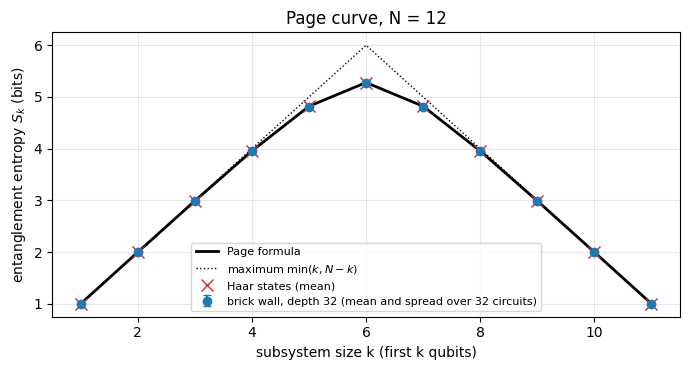

max |<S_k> - Page| :  Haar states 0.0037 bit,  deep brick-wall circuits 0.0142 bit


In [14]:
# ==============================================================================
# STEP 6: Page curve -- entropy of the first k qubits for deep-circuit states and for Haar states (N = 12)
# ==============================================================================
N_pg = 12
cuts = list(range(1, N_pg))
entropy_profile = jax.jit(lambda psi: jnp.stack([entanglement_entropy(psi, list(range(k))) for k in cuts]))

profile_circuit = np.asarray(jax.vmap(entropy_profile)(results[N_pg][0]))                         # (circuits, cuts)
haar_batch = jax.vmap(lambda k: haar_state(k, N_pg))(jax.random.split(jax.random.PRNGKey(8), N_CIRCUITS))
profile_haar = np.asarray(jax.vmap(entropy_profile)(haar_batch))
profile_page = np.array([page_entropy_bits(2 ** k, 2 ** (N_pg - k)) for k in cuts])

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(cuts, profile_page, "k-", lw=2, label="Page formula")
ax.plot(cuts, np.minimum(cuts, N_pg - np.array(cuts)), "k:", lw=1, label=r"maximum $\min(k, N-k)$")
ax.errorbar(cuts, profile_circuit.mean(0), yerr=profile_circuit.std(0), fmt="o", ms=6, capsize=3,
            label=f"brick wall, depth {2 * N_DOUBLE} (mean and spread over {N_CIRCUITS} circuits)")
ax.plot(cuts, profile_haar.mean(0), "x", ms=8, color="C3", label="Haar states (mean)")
ax.set_xlabel("subsystem size k (first k qubits)")
ax.set_ylabel(r"entanglement entropy $S_k$ (bits)")
ax.set_title(f"Page curve, N = {N_pg}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
dev_haar = np.max(np.abs(profile_haar.mean(0) - profile_page))
dev_circ = np.max(np.abs(profile_circuit.mean(0) - profile_page))
print(f"max |<S_k> - Page| :  Haar states {dev_haar:.4f} bit,  deep brick-wall circuits {dev_circ:.4f} bit")
assert dev_haar < 0.05

The Haar states follow Page's formula to within about a hundredth of a bit (the fluctuations from state to state are
tiny - a manifestation of *typicality*: almost every state has almost exactly the average entropy). The deep brick-wall
states lie on the same curve; any remaining deviation is located at the central cuts, which are the last to
saturate.

## 7. The single-qubit Clifford group

### 7.1 Definition and construction

Haar-random unitaries form a continuum. For many purposes a *finite* set of gates is just as good. The
**Clifford group** consists of the unitaries that map Pauli operators to Pauli operators under conjugation,

$$ C\,P\,C^\dagger = \pm P' ,\qquad P,P'\in\{X,Y,Z\}. $$

It is generated by $H$ and $S$ (plus CNOT for several qubits) - precisely the gates that notebook 09 singled out as
"not universal". How many single-qubit Cliffords are there? $C$ is fixed (up to a global phase) by the images of $X$
and $Z$: $X$ can go to any of the 6 signed Paulis $\pm X,\pm Y,\pm Z$; $Z$ must go to a signed Pauli that anticommutes
with the image of $X$: 4 choices. Hence $6\times4=$ **24 elements** - geometrically, the 24 rotations that map a cube
(or the octahedron formed by the six Pauli eigenstates on the Bloch sphere) onto itself.

The engine constructs the group by brute force: start from the identity, multiply by the generators $H$ and $S$,
keep every matrix not seen before (breadth-first search), until nothing new appears. To compare matrices "up to a
global phase" each one is brought to a canonical form in which its first non-zero entry is real and positive.

In [15]:
# ==============================================================================
# FINAL ENGINE VERSION  (verbatim from quantum_engine.py -- this is what later notebooks reuse)
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [16]:
# ==============================================================================
# CHECKPOINT: 24 elements, closure under multiplication, Paulis are mapped to signed Paulis
# ==============================================================================
cliffords = single_qubit_cliffords()                                   # shape (24, 2, 2)
print("number of single-qubit Clifford gates:", cliffords.shape[0])
assert cliffords.shape[0] == 24

# closure: |Tr(A^dag B)|/2 = 1 iff A = B up to a phase; every product C_a C_b must match exactly one element
products = jnp.einsum("aij,bjk->abik", cliffords, cliffords).reshape(-1, 2, 2)                  # all 576 products
overlap = jnp.abs(jnp.einsum("cij,pij->pc", cliffords.conj(), products)) / 2                     # (576, 24)
matches = jnp.sum(overlap > 1 - 1e-6, axis=1)
print("closure: every product C_a C_b is again in the set:", bool(jnp.all(matches == 1)))
assert bool(jnp.all(matches == 1))

# action on Paulis: C P C^dag = sign * P'
paulis = {"X": X, "Y": Y, "Z": Z}


def pauli_image(C, P):
    """Return the string '+X', '-Y', ... such that C P C^dag = +-P'."""
    M = C @ P @ C.conj().T
    for name, Q in paulis.items():
        c = float(jnp.real(jnp.trace(Q @ M)) / 2)
        if abs(abs(c) - 1) < 1e-6:
            return ("+" if c > 0 else "-") + name
    raise ValueError("not a Clifford gate")


images = [(pauli_image(C, X), pauli_image(C, Z)) for C in cliffords]
print("distinct (image of X, image of Z) pairs:", len(set(images)))
assert len(set(images)) == 24
print("first six elements:  X ->, Z -> :", images[:6])
try:
    pauli_image(T, X)
except ValueError:
    print("T X T^dag is not a Pauli operator: T is NOT a Clifford gate")

number of single-qubit Clifford gates: 24


closure: every product C_a C_b is again in the set: True


distinct (image of X, image of Z) pairs: 24
first six elements:  X ->, Z -> : [('+X', '+Z'), ('+Z', '+X'), ('+Y', '+Z'), ('+Z', '+Y'), ('-Y', '+X'), ('-X', '+Z')]
T X T^dag is not a Pauli operator: T is NOT a Clifford gate


The search finds exactly 24 gates, they form a group (closure), and they realise all 24 admissible ways of mapping
$(X,Z)$ to signed Paulis. The $T$ gate fails the test: $TXT^\dagger=(X+Y)/\sqrt2$.

### 7.2 How random is the Clifford group? Frame potentials

A finite set $\mathcal E=\{U_a\}$ is called a **unitary $t$-design** if averaging any polynomial of degree $\le t$ in
the matrix elements of $U$ (and $t$ in those of $U^*$) over $\mathcal E$ gives the same result as averaging over the
Haar measure. A convenient single-number test is the **frame potential**

$$ \mathcal F_t(\mathcal E)=\frac{1}{|\mathcal E|^2}\sum_{a,b}\big\lvert\mathrm{Tr}(U_a^\dagger U_b)\big\rvert^{2t}\;\ge\;\mathcal F_t^{\rm Haar}, $$

with equality if and only if $\mathcal E$ is a $t$-design (quoted; see Gross, Audenaert and Eisert 2007). Because
$U_a^\dagger U_b$ is itself Haar distributed when $U_a,U_b$ are independent Haar, the Haar value is a single moment,
$\mathcal F_t^{\rm Haar}=\mathbb E\lvert\mathrm{Tr}\,U\rvert^{2t}$. In dimension $d$ this moment equals $t!$ as long as
$t\le d$ (Diaconis and Shahshahani 1994: $\mathrm{Tr}\,U$ behaves like a standard complex Gaussian until the finite
size of the matrix is felt); for $t>d$ it is smaller. For $d=2$ the four values we need are the Catalan numbers
$\mathcal F_t^{\rm Haar}=1,2,5,14$ for $t=1,2,3,4$ - equal to $t!$ for $t=1,2$ and below it for $t=3,4$.
We compute $\mathcal F_t$ for the Clifford group exactly (a $24\times24$
table of overlaps), for the four Paulis $\{\mathbb 1,X,Y,Z\}$ (the full Pauli group also contains the phases
$\pm1,\pm i$, which cancel in $\lvert\mathrm{Tr}(U_a^\dagger U_b)\rvert$ and change nothing), and estimate the Haar
value by Monte Carlo as a sanity check.

In [17]:
# ==============================================================================
# STEP 7: frame potentials of the Pauli group, the Clifford group and (Monte Carlo) the Haar measure
# ==============================================================================
def frame_potential(gates, t):
    """F_t = mean over all pairs of |Tr(U_a^dag U_b)|^(2t)."""
    overlaps = jnp.abs(jnp.einsum("aij,bij->ab", gates.conj(), gates))
    return float(jnp.mean(overlaps ** (2 * t)))


pauli_group = jnp.stack([I2, X, Y, Z])
haar_set = jax.vmap(lambda k: haar_unitary(k, 2))(jax.random.split(jax.random.PRNGKey(9), 200000))
haar_traces = jnp.abs(jnp.trace(haar_set, axis1=1, axis2=2))           # |Tr U|: by invariance, Tr(U_a^dag U_b) ~ Tr U

print(f"{'t':>2s} {'Pauli group':>12s} {'Clifford group':>15s} {'Haar (exact)':>13s} {'Haar (Monte Carlo)':>22s}")
for t, exact in zip((1, 2, 3, 4), (1, 2, 5, 14)):
    sample = haar_traces ** (2 * t)
    mc, mc_err = float(jnp.mean(sample)), float(jnp.std(sample) / np.sqrt(sample.shape[0]))
    print(f"{t:2d} {frame_potential(pauli_group, t):12.3f} {frame_potential(cliffords, t):15.3f} {exact:13d} "
          f"{mc:14.3f} +- {mc_err:.3f}")

 t  Pauli group  Clifford group  Haar (exact)     Haar (Monte Carlo)


 1        1.000           1.000             1          1.001 +- 0.002
 2        4.000           2.000             2          2.003 +- 0.007


 3       16.000           5.000             5          5.011 +- 0.023


 4       64.000          15.000            14         14.034 +- 0.079


The four Paulis match Haar only for $t=1$ (they form a 1-design: averaging over random Paulis completely depolarises a
qubit - the content of the depolarising channel in notebook 07). The Clifford group matches for $t=1,2,3$ and
deviates at $t=4$ ($15$ instead of $14$): **the Clifford group is a unitary 3-design, but not a 4-design** (Webb 2016; Zhu 2017).
Protocols whose analysis involves only second or third moments - randomised benchmarking, classical shadows - can
therefore replace Haar-random unitaries by random Clifford gates, which are easy to implement and to track classically.
But Clifford circuits are *not* generic in every respect: they generate no "magic", their output distributions are
flat on their support instead of Porter-Thomas (next section), and they can be simulated efficiently.

## 8. Random circuit sampling with a discrete gate set

### 8.1 The task and a jit-friendly circuit model

**Random circuit sampling** is the task: given a random circuit, produce bit strings $s$ distributed according to
$p_s=\lvert\langle s\rvert U_{\rm circuit}\lvert0\dots0\rangle\rvert^2$. A quantum processor does this natively: run, measure, repeat.
A classical computer has to compute the amplitudes, which for generic circuits is believed to require exponential
resources.

Real devices do not apply Haar-random gates but gates from a small native set. We use the one-qubit gates
$\{H,X,Y,Z,S,T,R_x(\theta),R_y(\theta),R_z(\theta)\}$ with random angles and the two-qubit gates $\{\mathrm{CNOT},\mathrm{CZ}\}$ of
notebook 09.

> **JAX practice: make randomness data.** If the *positions* of the gates were random, every circuit would have a
> different einsum structure and would need its own compilation - for a one-off circuit the compile time would exceed
> the run time by orders of magnitude. Instead we fix the skeleton (brick-wall bonds, one single-qubit gate per qubit
> and layer) and make the *choice of gate* a traced integer: `table[kind]` selects a matrix from a stacked table - a
> "gather", perfectly legal under `jit`. The identity is part of the two-qubit table, so gates can also be absent.
> One compiled program then runs every circuit of the family, and `lax.scan` keeps the compile time independent of depth.

full gate set   : norm 1.0000000000, D sum p^2 = 2.181, half-chain entropy = 4.073 bit
Clifford subset : norm 1.0000000000, D sum p^2 = 1.000, half-chain entropy = 5.000 bit
distinct values of D*p for the Clifford circuit: [1.]


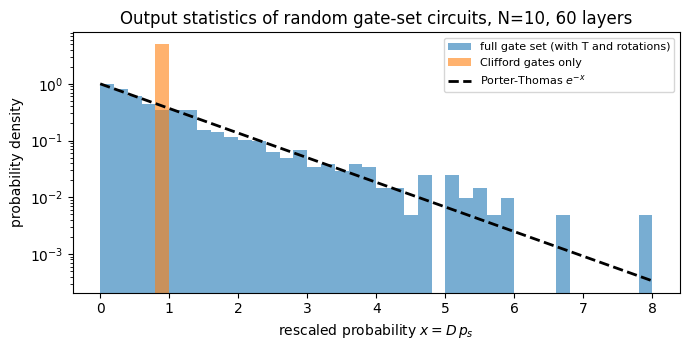

In [18]:
# ==============================================================================
# STEP 8: random circuits from a discrete gate set; gate choice = traced index into a table of matrices
# ==============================================================================
ONE_QUBIT_NAMES = ("H", "X", "Y", "Z", "S", "T", "Rx", "Ry", "Rz")
TWO_QUBIT_TABLE = jnp.stack([jnp.eye(4, dtype=CDTYPE), CNOT, CZ])         # index 0 = no gate


def one_qubit_gate(kind, theta):
    """Gate number `kind` of the set (H, X, Y, Z, S, T, Rx, Ry, Rz); `theta` is used by the rotations only."""
    return jnp.stack([H, X, Y, Z, S, T, rx(theta), ry(theta), rz(theta)])[kind]


def random_gateset_circuit(key, N, n_double, n_kinds=9):
    """Random circuit as a dict of integer/float arrays (leading axis = double layer).

    Every double layer: 1q gates on all qubits, 2q gates on even bonds, 1q gates on all qubits, 2q gates on odd bonds.
    n_kinds=9: full set;  n_kinds=5: only H, X, Y, Z, S  ->  a Clifford circuit.
    """
    k1, k2, k3 = jax.random.split(key, 3)
    return {"kind": jax.random.randint(k1, (n_double, 2, N), 0, n_kinds),
            "theta": jax.random.uniform(k2, (n_double, 2, N), minval=0.0, maxval=2 * jnp.pi),
            "pair": jax.random.randint(k3, (n_double, N - 1), 0, 3)}


def run_gateset_circuit(circuit, psi):
    """Execute a circuit produced by `random_gateset_circuit` (scan over double layers)."""
    N = psi.ndim

    def double_layer(psi, c):
        for parity in (0, 1):
            for q in range(N):
                psi = apply_gate(psi, one_qubit_gate(c["kind"][parity, q], c["theta"][parity, q]), [q])
            for q in range(parity, N - 1, 2):
                psi = apply_gate(psi, TWO_QUBIT_TABLE[c["pair"][q]], [q, q + 1])
        return psi, None

    psi, _ = lax.scan(double_layer, psi, circuit)                     # scan slices every array of the dict (a pytree)
    return psi


# PARAMETERS
N_rcs, L_rcs = 10, 30                                                  # qubits, double layers
D_rcs = 2 ** N_rcs
run_rcs = jax.jit(run_gateset_circuit)
psi_univ = run_rcs(random_gateset_circuit(jax.random.PRNGKey(10), N_rcs, L_rcs), zero_state(N_rcs))
psi_cliff = run_rcs(random_gateset_circuit(jax.random.PRNGKey(10), N_rcs, L_rcs, n_kinds=5), zero_state(N_rcs))

x_univ = np.asarray(D_rcs * jnp.abs(psi_univ.reshape(-1)) ** 2)
x_cliff = np.asarray(D_rcs * jnp.abs(psi_cliff.reshape(-1)) ** 2)
print(f"full gate set   : norm {float(jnp.linalg.norm(psi_univ)):.10f}, D sum p^2 = {np.mean(x_univ ** 2):.3f}, "
      f"half-chain entropy = {float(entanglement_entropy(psi_univ, list(range(N_rcs // 2)))):.3f} bit")
print(f"Clifford subset : norm {float(jnp.linalg.norm(psi_cliff)):.10f}, D sum p^2 = {np.mean(x_cliff ** 2):.3f}, "
      f"half-chain entropy = {float(entanglement_entropy(psi_cliff, list(range(N_rcs // 2)))):.3f} bit")
print("distinct values of D*p for the Clifford circuit:", np.unique(np.round(x_cliff, 6)))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(x_univ, bins=40, range=(0, 8), density=True, alpha=0.6, label="full gate set (with T and rotations)")
ax.hist(x_cliff, bins=40, range=(0, 8), density=True, alpha=0.6, label="Clifford gates only")
xx = np.linspace(0, 8, 100)
ax.plot(xx, np.exp(-xx), "k--", lw=2, label=r"Porter-Thomas $e^{-x}$")
ax.set_yscale("log")
ax.set_xlabel(r"rescaled probability $x = D\,p_s$")
ax.set_ylabel("probability density")
ax.set_title(f"Output statistics of random gate-set circuits, N={N_rcs}, {2 * L_rcs} layers")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

With the full gate set the output probabilities follow the Porter-Thomas law: a discrete universal gate set scrambles
like Haar-random gates - only more slowly, because a third of the two-qubit slots is empty and CNOT/CZ entangle less
than a typical Haar gate (after 60 layers the half-chain entropy is still below the Page value of 4.28 bit). The Clifford-only circuit
(same skeleton, gates restricted to $H,X,Y,Z,S$, CNOT, CZ) is also strongly entangled - with an *integer* number of
bits - yet its output distribution is completely different: $D\,p_s$ takes a single non-zero value. The state is a
**stabilizer state**, a superposition with equal weights (and phases $\pm1,\pm i$) over an affine subspace of bit
strings containing $2^k$ elements; in this instance the subspace is the whole space ($k=N$), so the measured bit strings are
*perfectly uniform* coin flips that reveal nothing about the entanglement inside. Entanglement alone does not make a state "generic"; the missing resource is the non-Clifford
*magic* supplied by $T$ gates or generic rotations (notebook 27, Chapter 9).

### 8.2 Sampling and the cost of classical simulation

Given the final state, sampling $M$ bit strings is a draw from the categorical distribution $p_s$ (`sample_bitstrings`,
[notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb)). Simulator and hardware are asymmetric here: a quantum device must rerun the
circuit for every shot, because the measurement destroys the state; the state-vector simulator computes the state once
and then draws as many samples as we like.

The cost of the simulation is $O(2^N)$ per gate in time and $16\times2^N$ bytes in memory (double precision). The cell
below measures it for $N=4\dots20$: compile time, run time of a circuit with 10 double layers and the time to draw 100
samples. For the sampling step we compare the engine's `sample_bitstrings` with a second sampler based on the inverse
cumulative distribution, defined (and validated) in the same cell.

first five samples (qubit 0 on the left): ['0100111010', '1111111100', '0011110100', '0001111110', '0000100100']


categorical (engine)  : D <p_s> over 50000 samples = 2.176 +- 0.007   (exact D sum p^2 = 2.181)


inverse CDF           : D <p_s> over 50000 samples = 2.180 +- 0.007   (exact D sum p^2 = 2.181)

  N  gates  compile+run (s)    run (s)    gates/s  100 shots: categorical (s)  inverse CDF (s)  state (MB)


  4    102             1.09     0.0040      25573                      0.0060           0.0021       0.000


  8    197             1.64     0.0053      36934                      0.0058           0.0025       0.004


 12    315             4.71     0.0194      16213                      0.0459           0.0028       0.066


 16    418             4.45     0.1962       2131                      0.4283           0.0073       1.049


 20    523             9.55     4.0845        128                      5.0767           0.0311      16.777


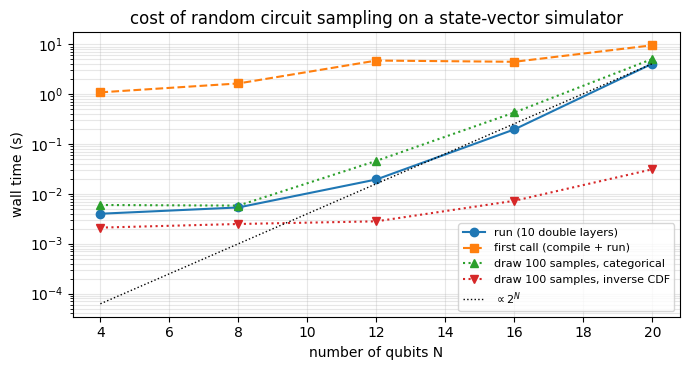

In [19]:
# ==============================================================================
# STEP 9: sampling bit strings; timing of circuit execution versus N (compile time and run time separated)
# ==============================================================================
def sample_bitstrings_cdf(key, psi, shots):
    """Sample bit strings by inversion of the cumulative distribution.

    MATH   c_i = sum_{j<=i} p_j ;  draw u ~ U(0,1) ;  the sample is the first index i with c_i >= u.
    COST   O(2^N) once for the cumulative sum + O(log 2^N) = O(N) per shot (binary search, `jnp.searchsorted`),
           instead of O(2^N) PER SHOT for `jax.random.categorical` (which draws one random number per outcome and shot).
    Returns an int array (shots, N), same convention as `sample_bitstrings`.
    """
    N = psi.ndim
    cdf = jnp.cumsum(jnp.abs(psi.reshape(-1)) ** 2)
    u = jax.random.uniform(key, (shots,), dtype=cdf.dtype) * cdf[-1]           # cdf[-1] = 1 up to rounding
    idx = jnp.clip(jnp.searchsorted(cdf, u), 0, 2 ** N - 1)
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


shots = sample_bitstrings(jax.random.PRNGKey(12), psi_univ, 100)                 # int array (100, N)
print("first five samples (qubit 0 on the left):", ["".join(map(str, np.asarray(b))) for b in shots[:5]])

# CHECKPOINT: both samplers must reproduce the collision probability  E_s[p_s] = sum_s p_s^2  within the error
p_univ = jnp.abs(psi_univ.reshape(-1)) ** 2
weights_rcs = 2 ** jnp.arange(N_rcs - 1, -1, -1)                                 # bit string -> flat index
for name, sampler in (("categorical (engine)", sample_bitstrings), ("inverse CDF", sample_bitstrings_cdf)):
    vals = D_rcs * p_univ[sampler(jax.random.PRNGKey(13), psi_univ, 50000) @ weights_rcs]
    mean, sem = float(jnp.mean(vals)), float(jnp.std(vals) / np.sqrt(vals.shape[0]))
    print(f"{name:22s}: D <p_s> over 50000 samples = {mean:.3f} +- {sem:.3f}   (exact D sum p^2 = {np.mean(x_univ ** 2):.3f})")
    assert abs(mean - np.mean(x_univ ** 2)) < 5 * sem

L_bench, SHOTS_bench = 10, 100
sizes = (4, 8, 12, 16, 20)
bench = []
print(f"\n{'N':>3s} {'gates':>6s} {'compile+run (s)':>16s} {'run (s)':>10s} {'gates/s':>10s} {'100 shots: categorical (s)':>27s} "
      f"{'inverse CDF (s)':>16s} {'state (MB)':>11s}")
for N in sizes:
    circuit = random_gateset_circuit(jax.random.PRNGKey(N), N, L_bench)
    n_gates = int(L_bench * 2 * N + jnp.sum(circuit["pair"] > 0))               # identity "pairs" do not count as gates
    runner = jax.jit(run_gateset_circuit)
    t0 = time.perf_counter()
    runner(circuit, zero_state(N)).block_until_ready()
    t_first = time.perf_counter() - t0
    t0 = time.perf_counter()
    psi = runner(circuit, zero_state(N)).block_until_ready()
    t_run = time.perf_counter() - t0
    t_shots = []
    for sampler in (sample_bitstrings, sample_bitstrings_cdf):
        sampler(jax.random.PRNGKey(0), psi, SHOTS_bench).block_until_ready()         # warm-up (compilation)
        t0 = time.perf_counter()
        sampler(jax.random.PRNGKey(1), psi, SHOTS_bench).block_until_ready()
        t_shots.append(time.perf_counter() - t0)
    bench.append((N, t_first, t_run, t_shots[0], t_shots[1]))
    print(f"{N:3d} {n_gates:6d} {t_first:16.2f} {t_run:10.4f} {n_gates / t_run:10.0f} {t_shots[0]:27.4f} {t_shots[1]:16.4f} "
          f"{16 * 2 ** N / 1e6:11.3f}")

bench = np.array(bench)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.semilogy(bench[:, 0], bench[:, 2], "o-", label=f"run ({L_bench} double layers)")
ax.semilogy(bench[:, 0], bench[:, 1], "s--", label="first call (compile + run)")
ax.semilogy(bench[:, 0], bench[:, 3], "^:", label=f"draw {SHOTS_bench} samples, categorical")
ax.semilogy(bench[:, 0], bench[:, 4], "v:", label=f"draw {SHOTS_bench} samples, inverse CDF")
ax.semilogy(bench[:, 0], bench[-1, 2] * 2.0 ** (bench[:, 0] - bench[-1, 0]), "k:", lw=1, label=r"$\propto 2^N$")
ax.set_xlabel("number of qubits N")
ax.set_ylabel("wall time (s)")
ax.set_title("cost of random circuit sampling on a state-vector simulator")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

For small registers the run time grows far more slowly than $2^N$ - it is dominated by fixed overheads (one kernel
launch per gate, the random-number generation), not by arithmetic - and the compile
time dominates everything. Beyond $N\approx12$ the run time grows by a factor of roughly 16 for every four added qubits,
following the $2^N$ line. The two samplers give statistically equivalent samples (checkpoint above), but their costs differ: `jax.random.categorical`
draws one random number per outcome *and per shot*, $O(M\,2^N)$, and at $N=20$ drawing 100 bit strings costs as much as
running the whole circuit; inversion of the cumulative distribution costs $O(2^N)$ once plus a binary search per shot and
stays cheap. Each additional qubit also doubles the memory: at 16 bytes per amplitude, $N=20$ needs 17 MB, $N=30$ needs 17 GB and $N=50$
would need 18 petabytes. This exponential wall is what gives random circuit sampling on 50+ qubits its significance.
(Absolute numbers depend on the machine and its load; the scaling does not.)

## 9. Cross-entropy benchmarking (XEB)

### 9.1 The idea

Suppose a device returns bit strings $s_1,\dots,s_M$ after running a random circuit. How do we know whether it worked?
We cannot compare histograms - for 50 qubits there are $10^{15}$ possible outcomes and every observed string occurs
once. The linear cross-entropy benchmark uses the *ideal* probabilities $p_s$ computed by a classical simulation
and asks: **did the device preferentially output the bit strings that the ideal circuit makes likely?**

$$ \mathcal F_{\rm XEB} = D\,\overline{p_{s_i}}-1 = \frac DM\sum_{i=1}^Mp_{s_i}-1 . $$

Three cases show what it measures:

* *Perfect device*: $s_i$ is drawn from $p$ itself, so $\mathbb E[p_{s_i}]=\sum_sp_s\cdot p_s$, the collision
  probability, and $\mathcal F_{\rm XEB}=D\sum_sp_s^2-1\approx 2-1=1$ by Porter-Thomas.
* *Useless device* (uniformly random bit strings): $\mathbb E[p_{s_i}]=\sum_s\frac1Dp_s=\frac1D$, so $\mathcal F_{\rm XEB}=0$.
* *Noisy device*, modelled as $\rho=F\lvert\psi\rangle\langle\psi\rvert+(1-F)\,\mathbb 1/D$ (with probability $F$ nothing went wrong,
  otherwise the output is completely scrambled): by linearity $\mathcal F_{\rm XEB}=F\,(D\sum_sp_s^2-1)\approx F$.

So the XEB estimates the **fidelity** of the device - from samples alone, without state tomography. For finite $D$ and
finite depth $D\sum p_s^2$ is not exactly 2; since we know the ideal $p_s$ we can normalise,
$\mathcal F_{\rm XEB}^{\rm norm} = (D\,\overline{p_{s_i}}-1)/(D\sum_sp_s^2-1)$. The statistical error of the estimate is
$\approx1/\sqrt M$, because $Dp_{s_i}$ has a variance of order one.

Two assumptions are hidden in the third bullet and should be stated plainly, because they are what the argument rests
on and they are not automatic:

1. **The noise is global white noise.** Only for $\rho=F\lvert\psi\rangle\langle\psi\rvert+(1-F)\mathbb 1/D$ does the
   linearity step go through. Real devices have *local* errors; that they add up to something close to global white
   noise is a property of deep scrambling circuits, not a theorem about arbitrary circuits (Boixo *et al.* 2018).
   Section 9.3 tests exactly this: local depolarising noise is put in, and the global-white-noise prediction comes out.
2. **The ideal distribution is anticoncentrated.** $D\sum_sp_s^2-1$ is the signal; if the circuit is too shallow this
   number is far from 1 and the normalisation is doing most of the work (Exercise 8).

The XEB is therefore an estimator of fidelity *under a noise model*, not a model-free measurement of it, and it can be
fooled: classical algorithms are known that produce a large $\mathcal F_{\rm XEB}$ without preparing the state at all
(Gao *et al.* 2024). It remains the standard diagnostic because nothing cheaper exists at 50 qubits.

### 9.2 Ideal versus uniform samples

In [20]:
# ==============================================================================
# STEP 10: linear XEB from samples -- perfect sampler versus uniformly random bit strings
# ==============================================================================
def xeb_from_samples(p_ideal, samples_flat):
    """Normalised linear XEB and its standard error from flat sample indices.

    MATH   F = (D <p_ideal(s_i)> - 1) / (D sum_s p_s^2 - 1)
    """
    D = p_ideal.shape[0]
    values = D * p_ideal[samples_flat]                                 # D * p(s_i) for every sample: a gather
    norm = D * jnp.sum(p_ideal ** 2) - 1.0
    return float((jnp.mean(values) - 1.0) / norm), float(jnp.std(values) / jnp.sqrt(values.shape[0]) / norm)


# PARAMETERS
N_xeb, L_xeb = 10, 8                                                   # Haar brick wall: 2*L_xeb = 16 layers
D_xeb = 2 ** N_xeb
circuit_xeb = random_brickwall_circuit(jax.random.PRNGKey(20), N_xeb, L_xeb)
psi_ideal, _ = jax.jit(run_brickwall)(circuit_xeb, zero_state(N_xeb))
p_ideal = jnp.abs(psi_ideal.reshape(-1)) ** 2
print(f"ideal circuit: D sum p^2 = {float(D_xeb * jnp.sum(p_ideal ** 2)):.3f}")

bit_weights = 2 ** jnp.arange(N_xeb - 1, -1, -1)                       # bit string -> flat index (qubit 0 = most significant)
print(f"\n{'shots':>8s} {'XEB, ideal sampler':>24s} {'XEB, uniform sampler':>26s}")
for M in (100, 1000, 10000, 100000):
    k_a, k_b = jax.random.split(jax.random.PRNGKey(M))
    ideal_idx = sample_bitstrings(k_a, psi_ideal, M) @ bit_weights
    uniform_idx = jax.random.randint(k_b, (M,), 0, D_xeb)
    f_i, e_i = xeb_from_samples(p_ideal, ideal_idx)
    f_u, e_u = xeb_from_samples(p_ideal, uniform_idx)
    print(f"{M:8d} {f_i:14.3f} +- {e_i:.3f} {f_u:16.3f} +- {e_u:.3f}")

ideal circuit: D sum p^2 = 2.064

   shots       XEB, ideal sampler       XEB, uniform sampler


     100          0.998 +- 0.152            0.125 +- 0.102


    1000          0.942 +- 0.042            0.015 +- 0.030


   10000          1.005 +- 0.014            0.003 +- 0.010


  100000          0.998 +- 0.004            0.000 +- 0.003


Samples from the ideal distribution give $\mathcal F_{\rm XEB}\to1$, uniformly random strings give
$\mathcal F_{\rm XEB}\to0$, and the error bars shrink as $1/\sqrt M$. With $10^5$ shots the two cases are separated
by hundreds of standard errors, although $10^5$ samples from $2^{10}$ outcomes could also have been distinguished by a
histogram - the point of XEB is that the same estimator keeps working when $D$ is astronomically large, where the
number of shots needed depends on the fidelity ($M\gtrsim1/F^2$) but not on $D$.

### 9.3 A noisy device: XEB tracks the fidelity

We now simulate a noisy processor with the quantum-trajectory method of notebooks 07 and 09: after every two-qubit
gate each of its two qubits suffers a depolarising channel with error probability $p$ (`apply_kraus_mcwf` samples one Kraus
operator per noise location). Every trajectory is one "run of the device": it ends in some pure state
$\lvert\psi_{\rm traj}\rangle$ from which we draw **one** bit string - exactly what an experiment delivers. From the same
trajectories we can also compute what no experiment can access directly, the true fidelity
$F=\overline{\lvert\langle\psi_{\rm ideal}\vert\psi_{\rm traj}\rangle\rvert^2}$, and compare it with the XEB estimate and with the
simple prediction $(1-p)^{n_{\rm loc}}$, the probability that no error occurred at any of the $n_{\rm loc}$ noise locations.

The execution reuses the scan-over-double-layers structure; the noise level `p` is a traced argument, so the whole sweep
over `p` uses a single compilation, and `vmap` runs all trajectories in parallel.

N=10, 16 layers, 72 two-qubit gates, 144 noise locations, 2500 trajectories per noise level

      p         XEB estimate        true fidelity  (1-p)^n_loc


  0.000        0.994 +- 0.027        1.000 +- 0.000        1.000


  0.002        0.743 +- 0.027        0.745 +- 0.009        0.750


  0.005        0.514 +- 0.026        0.500 +- 0.010        0.486


  0.010        0.255 +- 0.024        0.241 +- 0.008        0.235


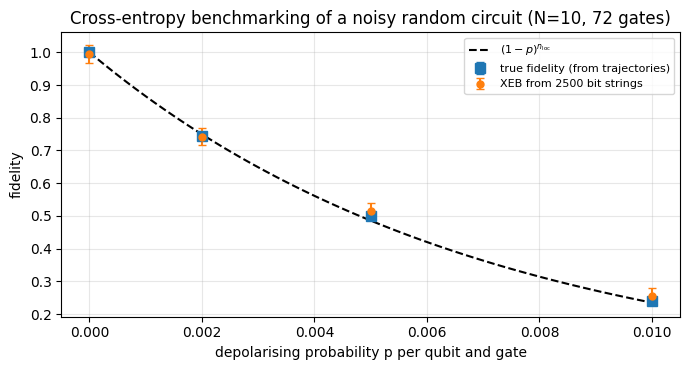

In [21]:
# ==============================================================================
# STEP 11: noisy random circuit sampling with quantum trajectories: XEB versus true fidelity
# ==============================================================================
def noisy_brickwall_trajectory(key, circuit, psi, p):
    """One trajectory: brick-wall circuit with depolarising noise (probability p) on both qubits after every gate."""
    kraus = kraus_depolarizing(p)

    def noisy_layer(psi, U_layer, parity, key):
        for j in range(U_layer.shape[0]):
            bond = (parity + 2 * j, parity + 2 * j + 1)
            psi = apply_gate(psi, U_layer[j], bond)
            for q in bond:
                key, sub = jax.random.split(key)
                psi = apply_kraus_mcwf(sub, psi, kraus, [q])
        return psi

    def double_layer(psi, xs):
        U_even_l, U_odd_l, k = xs
        k_even, k_odd = jax.random.split(k)
        psi = noisy_layer(psi, U_even_l, 0, k_even)
        return noisy_layer(psi, U_odd_l, 1, k_odd), None

    n_double = circuit[0].shape[0]
    psi, _ = lax.scan(double_layer, psi, (circuit[0], circuit[1], jax.random.split(key, n_double)))
    return psi


@jax.jit
def noisy_device_run(keys, p):
    """For every key: run one noisy trajectory, draw ONE bit string from it.  Returns (sample indices, fidelities)."""
    def one(key):
        k_traj, k_shot = jax.random.split(key)
        psi = noisy_brickwall_trajectory(k_traj, circuit_xeb, zero_state(N_xeb), p)
        probs = jnp.abs(psi.reshape(-1)) ** 2
        shot = jax.random.categorical(k_shot, jnp.log(jnp.clip(probs, 1e-300, None)))
        return shot, fidelity_pure(psi_ideal, psi)
    return jax.vmap(one)(keys)


M_TRAJ = 2500
noise_levels = (0.0, 0.002, 0.005, 0.01)
n_loc = 2 * L_xeb * ((N_xeb // 2) + (N_xeb - 1) // 2)                  # two noise locations per two-qubit gate
print(f"N={N_xeb}, {2 * L_xeb} layers, {n_loc // 2} two-qubit gates, {n_loc} noise locations, {M_TRAJ} trajectories per noise level\n")
print(f"{'p':>7s} {'XEB estimate':>20s} {'true fidelity':>20s} {'(1-p)^n_loc':>12s}")
rows = []
for i, p in enumerate(noise_levels):
    shots_p, fids = noisy_device_run(jax.random.split(jax.random.PRNGKey(30 + i), M_TRAJ), p)
    f_xeb, e_xeb = xeb_from_samples(p_ideal, shots_p)
    f_true, e_true = float(jnp.mean(fids)), float(jnp.std(fids) / np.sqrt(M_TRAJ))
    rows.append((p, f_xeb, e_xeb, f_true, e_true, (1 - p) ** n_loc))
    print(f"{p:7.3f} {f_xeb:12.3f} +- {e_xeb:.3f} {f_true:12.3f} +- {e_true:.3f} {(1 - p) ** n_loc:12.3f}")
rows = np.array(rows)

fig, ax = plt.subplots(figsize=(7, 3.8))
pp = np.linspace(0, max(noise_levels), 100)
ax.plot(pp, (1 - pp) ** n_loc, "k--", lw=1.5, label=r"$(1-p)^{n_{\rm loc}}$")
ax.errorbar(rows[:, 0], rows[:, 3], yerr=rows[:, 4], fmt="s", ms=7, capsize=3, label="true fidelity (from trajectories)")
ax.errorbar(rows[:, 0], rows[:, 1], yerr=rows[:, 2], fmt="o", ms=5, capsize=3, label=f"XEB from {M_TRAJ} bit strings")
ax.set_xlabel("depolarising probability p per qubit and gate")
ax.set_ylabel("fidelity")
ax.set_title(f"Cross-entropy benchmarking of a noisy random circuit (N={N_xeb}, {n_loc // 2} gates)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At $p=0$ every trajectory is the ideal state (fidelity exactly 1) and the XEB is 1 within its statistical error. With
noise, the XEB estimated from one bit string per run follows the true fidelity within one to two of its error bars, and both follow
the simple law $(1-p)^{n_{\rm loc}}$: in a scrambling circuit *a single Pauli error anywhere* makes the state almost
orthogonal to the ideal one, so the fidelity is just the probability of an error-free run. (Small systematic
differences are expected: errors in the last layers do not have time to spread, which affects XEB and fidelity
slightly differently.) This is how the fidelity $\sim0.2\%$ of the 53-qubit, 20-cycle experiment of Arute *et al.* was
certified - and why error rates have to fall well below $1/(\text{number of gates})$ before large circuits become
useful.

### 9.4 How far the method reaches

As a last experiment we push the brick-wall simulation to $N=20$ qubits - a state of $2^{20}\approx10^6$ amplitudes -
with 20 layers, and compute the half-chain entropy from the singular values of a $1024\times1024$ matrix.

In [22]:
# ==============================================================================
# STEP 12: one big run -- N = 20, 20 layers
# ==============================================================================
N_big, L_big = 20, 10
circuit_big = random_brickwall_circuit(jax.random.PRNGKey(40), N_big, L_big)
final_only = jax.jit(lambda c, psi: run_brickwall(c, psi, observe=lambda s: jnp.zeros(()))[0])   # skip per-layer SVDs
t0 = time.perf_counter()
psi_big = final_only(circuit_big, zero_state(N_big)).block_until_ready()
t_big = time.perf_counter() - t0
ent_big = float(entanglement_entropy(psi_big, list(range(N_big // 2))))
n_gates_big = L_big * (N_big - 1)
print(f"N={N_big}: {n_gates_big} Haar gates on {2 ** N_big} amplitudes in {t_big:.1f} s (including compilation)")
print(f"norm = {float(jnp.linalg.norm(psi_big)):.12f}")
print(f"half-chain entropy after {2 * L_big} layers: {ent_big:.3f} bit   "
      f"(Page value {page_entropy_bits(2 ** 10, 2 ** 10):.3f} bit, maximum {N_big // 2})")
print(f"D sum p^2 = {float(2 ** N_big * jnp.sum(jnp.abs(psi_big) ** 4)):.4f}")

N=20: 190 Haar gates on 1048576 amplitudes in 2.3 s (including compilation)


norm = 1.000000000000
half-chain entropy after 20 layers: 6.534 bit   (Page value 9.279 bit, maximum 10)


D sum p^2 = 2.1297


Twenty layers bring the collision probability to within about 7 % of the Porter-Thomas value ($D\sum p^2=2.13$
against 2) but nowhere near entanglement saturation: the entropy is still far below the Page value. The 7 % is not
statistical noise - a genuine Haar state at $D=2^{20}$ scatters by only $2/\sqrt D=0.002$ - so the circuit is
*close to* anticoncentrated rather than Haar-like, and the gap is still shrinking with depth. Divide the two printed numbers - about 6.5 bits
after 20 layers is about 0.33 bit per layer, the same few-tenths-of-a-bit rate as in Section 6.3 - and at
this rate reaching the Page value of 9.28 bits would need some 30 layers: the saturation depth grows proportionally to
$N$, while the collision probability is already within a few per cent of its final value. The two time scales really
are different: for brick-wall circuits anticoncentration sets in after a depth $O(\log N)$ (Dalzell, Hunter-Jones and
Brandão 2022), whereas the entanglement needs a depth $O(N)$ to saturate (Nahum *et al.* 2017).
*Anticoncentration is fast, scrambling is slow.*

## 10. Summary - key takeaways

* "Uniformly random" unitaries/states are defined by **invariance** (Haar measure). Uniform parameters (Euler angles)
  are *not* uniform unitaries.
* **Haar states**: normalise a complex Gaussian vector - $O(2^N)$. **Haar unitaries**: QR-decompose a Ginibre matrix
  **and fix the phases** with the diagonal of $R$ (Mezzadri). Without the fix the matrices are unitary but not Haar -
  visible in the eigenphase density. Validate samplers statistically, with error bars.
* Output probabilities of random states are exponentially distributed (**Porter-Thomas**), $D\sum_sp_s^2\to2$.
* **Random brick-wall circuits** are minimal models of chaotic local dynamics: entanglement grows linearly with depth
  and saturates at the **Page value** $N/2-1/(2\ln2)$ bits after a depth $\propto N$; Porter-Thomas statistics appears
  much earlier.
* The 24-element single-qubit **Clifford group** reproduces Haar averages up to the third moment (3-design) and fails
  at the fourth; Clifford circuits entangle but their outputs are not Porter-Thomas.
* **XEB** $=D\,\overline{p_{s_i}}-1$ estimates the fidelity of a noisy random-circuit experiment from bit strings;
  in a scrambling circuit $F\approx(1-p)^{n_{\rm loc}}$.
* JAX pattern of this notebook: *randomness is data, structure is static* - circuits as arrays of matrices or gate
  indices, `scan` over layers, `vmap` over keys (circuits, trajectories, samples), one compilation per shape.

## 11. Exercises

1. ★ **A wrong state sampler.** Normalise vectors whose real and imaginary parts are *uniform* in $[-1,1]$ and show, for
   one qubit, that the histogram of $\langle Z\rangle$ is not flat. Which step of the proof in Section 3 fails?
2. ★ **Exact finite-size Porter-Thomas law.** Show numerically that the matrix element $p=\lvert U_{00}\rvert^2$ of a Haar
   unitary follows the density $(d-1)(1-p)^{d-2}$ for $d=2$, $4$ and $8$ (histogram against the formula). What does
   the formula say for a single qubit, and where did we already see this in Section 2?
3. ★★ **Level repulsion.** For Haar unitaries with $d=16$ compute the spacings between neighbouring eigenphases (in units
   of the mean spacing $2\pi/d$) and histogram them. Compare with independent uniformly random phases (Poisson:
   $e^{-s}$) and with the Wigner surmise of the unitary ensemble, $\frac{32}{\pi^2}s^2e^{-4s^2/\pi}$.
4. ★★ **Entanglement velocity (physics).** From the data of Section 6.3 extract the growth rate of the half-chain entropy in
   bits per layer in the linear regime, with an error bar. Repeat with the second Rényi entropy (`renyi2_entropy` in
   notebook 06). Which grows more slowly? Then replace the Haar gates by a fixed gate, e.g. `CNOT @ kron(ry(a), ry(b))`
   with random angles, and compare.
5. ★★ **Periodic boundary conditions (extend the code).** Add the bond $(N-1,0)$ to the odd layers in
   `apply_bond_layer`/`random_brickwall_circuit` (for even $N$). The region $A=\{0..N/2-1\}$ now has two boundaries. How
   do the growth rate and the saturation depth change?
6. ★★ **Clifford 2-design property.** Show numerically that for a fixed state $\lvert\psi\rangle$ the average of
   $\lvert\langle0\rvert C\lvert\psi\rangle\rvert^{2t}$ over the 24 Cliffords equals the Haar value $t!/(d(d+1)\cdots(d+t-1))$,
   here with $d=2$, i.e. $1/2$, $1/3$, $1/4$ for $t=1,2,3$ and any $\lvert\psi\rangle$, but depends on
   $\lvert\psi\rangle$ for $t=4$ (the Haar value there is $1/5$). For which states is the deviation largest?
7. ★★★ **$T$-doped Clifford circuits (extend the code).** Add a parameter to `random_gateset_circuit` that controls the
   probability of drawing a non-Clifford gate ($T$). Measure how the histogram of $Dp_s$ crosses over from the
   stabilizer form (one non-zero value of $Dp_s$, the rest exactly zero) to Porter-Thomas as a function of the number
   of $T$ gates in the circuit.
8. ★★★ **XEB at shallow depth.** Repeat Section 9.3 with `L_xeb = 2`. Does the XEB still track the fidelity? Explain the
   discrepancy in terms of errors that have not had time to spread, and test whether the normalisation by
   $D\sum p^2-1$ helps.

## 12. References

* F. Mezzadri, *How to generate random matrices from the classical compact groups*, Notices of the AMS **54**(5),
  592-604 (2007).
* P. Diaconis and M. Shahshahani, *On the eigenvalues of random matrices*, J. Appl. Probab. **31A**, 49-62 (1994) -
  the moments $\mathbb E\lvert\mathrm{Tr}\,U\rvert^{2t}=t!$ for $t\le d$.
* C. E. Porter and R. G. Thomas, *Fluctuations of nuclear reaction widths*, Phys. Rev. **104**, 483 (1956).
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993).
* A. Nahum, J. Ruhman, S. Vijay and J. Haah, *Quantum entanglement growth under random unitary dynamics*,
  Phys. Rev. X **7**, 031016 (2017).
* M. P. A. Fisher, V. Khemani, A. Nahum and S. Vijay, *Random quantum circuits*, Annu. Rev. Condens. Matter Phys.
  **14**, 335 (2023).
* S. Boixo, S. V. Isakov, V. N. Smelyanskiy, R. Babbush, N. Ding, Z. Jiang, M. J. Bremner, J. M. Martinis and
  H. Neven, *Characterizing quantum supremacy in near-term devices*, Nature Physics **14**, 595 (2018).
* F. Arute *et al.*, *Quantum supremacy using a programmable superconducting processor*, Nature **574**, 505 (2019).
* A. M. Dalzell, N. Hunter-Jones and F. G. S. L. Brandão, *Random quantum circuits anticoncentrate in log depth*,
  PRX Quantum **3**, 010333 (2022).
* X. Gao, M. Kalinowski, C.-N. Chou, M. D. Lukin, B. Barak and S. Choi, *Limitations of linear cross-entropy as a
  measure for quantum advantage*, PRX Quantum **5**, 010334 (2024).
* D. Gross, K. Audenaert and J. Eisert, *Evenly distributed unitaries: on the structure of unitary designs*,
  J. Math. Phys. **48**, 052104 (2007).
* C. Dankert, R. Cleve, J. Emerson and E. Livine, *Exact and approximate unitary 2-designs and their application to
  fidelity estimation*, Phys. Rev. A **80**, 012304 (2009).
* Z. Webb, *The Clifford group forms a unitary 3-design*, Quantum Inf. Comput. **16**, 1379 (2016);
  H. Zhu, *Multiqubit Clifford groups are unitary 3-designs*, Phys. Rev. A **96**, 062336 (2017).
* D. Gottesman, *The Heisenberg representation of quantum computers*, arXiv:quant-ph/9807006 (1998).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes*, 3rd ed. (Cambridge
  University Press, 2007), Section 2.10 (*QR Decomposition*) and Section 7.3 (*Deviates from Other Distributions*);
  also *Numerical Recipes in Fortran 90*, 2nd ed. (Cambridge University Press, 1996).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/